# LENGTH OF STAY

In [2]:
pip install xgboost catboost

In [4]:
pip install shap==0.44.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 535.7/535.7 kB 5.3 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from math import sqrt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
import catboost as cb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import ElasticNet
%matplotlib inline



In [90]:
data = pd.read_excel("data_target_LOS.xlsx")
original_data = data
data

,Derivation cohort,Death,Severity,Black,White,Asian,Latino,MI,PVD,CHF,...,Sodium,Glucose,AST,ALT,WBC,Lympho,Ferritin,CrctProtein,Troponin,LOS
0,1,0,3,0,0,0,0,0,0,0,...,135.000000,112.000000,26.00000,14.000000,5.60000,1.400000,0.000000,0.499900,0.010000,1.0
1,1,1,7,0,1,0,0,0,1,0,...,137.000000,265.000000,85.00000,32.000000,12.20000,0.300000,885.000000,14.900000,1.200000,2.0
2,1,1,7,0,1,0,0,0,1,1,...,140.000000,121.000000,32.00000,18.000000,6.10000,0.500000,629.000000,33.900000,0.027512,2.0
3,1,0,9,1,0,0,0,1,0,0,...,132.000000,175.357053,44.00000,17.000000,3.70000,0.500000,816.000000,18.400000,0.050000,15.0
4,1,0,7,1,0,0,0,0,0,0,...,149.000000,176.740844,38.00000,28.000000,5.70000,1.400000,1691.000000,11.600000,0.010000,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4706,0,0,4,0,0,1,0,0,0,0,...,139.000000,97.000000,23.00000,24.000000,10.30000,1.000000,295.000000,1.800000,0.010000,4.0
4707,0,0,2,0,0,0,1,0,1,0,...,136.000000,165.771532,40.00000,30.000000,4.10000,1.200000,1165.000000,3.100000,0.010000,2.0
4708,0,0,1,0,0,0,0,0,1,0,...,136.000000,153.000000,26.00000,16.000000,7.40000,1.000000,239.000000,0.499900,0.000000,NaN
4709,0,0,3,1,0,0,0,0,1,0,...,137.000000,131.000000,31.00000,33.000000,7.60000,1.800000,1185.000000,8.600000,0.010000,NaN


## Vymazať prázdne hodnoty v cieľovej triede

In [91]:
data.dropna(inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4370 entries, 0 to 4707
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Derivation cohort  4370 non-null   int64  
 1   Death              4370 non-null   int64  
 2   Severity           4370 non-null   int64  
 3   Black              4370 non-null   int64  
 4   White              4370 non-null   int64  
 5   Asian              4370 non-null   int64  
 6   Latino             4370 non-null   int64  
 7   MI                 4370 non-null   int64  
 8   PVD                4370 non-null   int64  
 9   CHF                4370 non-null   int64  
 10  CVD                4370 non-null   int64  
 11  DEMENT             4370 non-null   int64  
 12  COPD               4370 non-null   int64  
 13  DM Complicated     4370 non-null   int64  
 14  DM Simple          4370 non-null   int64  
 15  Renal Disease      4370 non-null   int64  
 16  All CNS            4370 non-n

In [92]:
# Renaming columns
data = data.rename(columns={
    'LOS': 'Length_of_stay',
    'MI': 'Myocardial_infarction',
    'PVD': 'Per_vascular_dis',
    'CHF': 'Cong_heart_failure',
    'CVD': 'Cardiovascular_dis',
    'DEMENT': 'Dementia',
    'COPD': 'Chronic_obst_pulm_dis',
    'DM Complicated': 'Diabetes_mel_complicated',
    'DM Simple': 'Diabetes_mel_simple',
    'Renal Disease': 'Renal_dis',
    'All CNS': 'All_CNS',
    'Pure CNS': 'Pure_CNS',
    'OldOtherNeuro': 'Other_neuro_dis',
    'OtherBrnLsn': 'Other_brain_lesions',
    'Age.1': 'Age_number',
    'AgeScore': 'Age_category',
    'OsSats': 'Oxygen_sat',
    'Temp': 'Temperature',
    'MAP': 'Mean_art_press',
    'Plts': 'Platelets',
    'INR': 'Inter_norm_ratio',
    'BUN': 'Blood_urea_nitr',
    'WBC': 'White_blood_cells',
    'CrctProtein': 'CRP'
})


In [93]:
data['Per_vascular_dis'] = data['Per_vascular_dis'].replace(2, 1)

In [65]:
# Convert the column to integers
data['Length_of_stay'] = data['Length_of_stay'].astype(int)


In [66]:
data_copy = data.copy()

## Popis cieľového atribútu

<ipython-input-16-2c2e4f042624>:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(new_labels, fontsize=12)


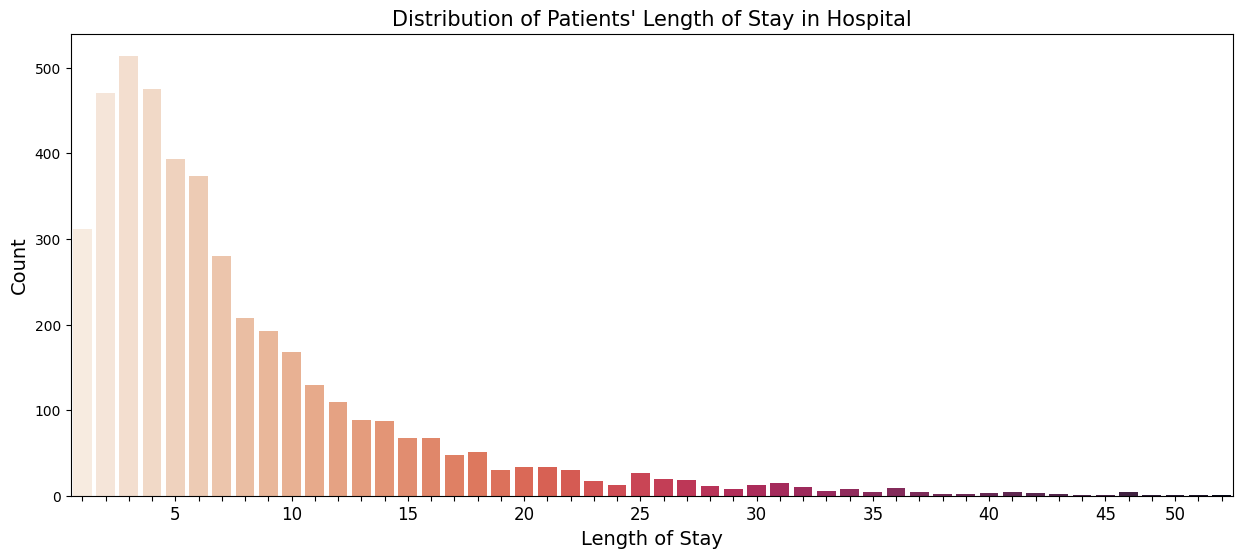

In [16]:
plt.figure(figsize=(15, 6))
sns.countplot(data=data, x="Length_of_stay", hue="Length_of_stay", palette="rocket_r", legend=False)

ax = plt.gca()

# Get the tick labels and their corresponding positions
labels = [label.get_text() for label in ax.get_xticklabels()]
positions = ax.get_xticks()

# Since we want to start from 1 and show every 5th label, we adjust our approach
start_pos = next(pos for pos, label in zip(positions, labels) if int(label) >= 1)
new_labels = ['' if int(label) % 5 != 0 else label for label in labels]
ax.set_xticklabels(new_labels, fontsize=12)
ax.set_xlabel("Length of Stay", fontsize=14)
ax.set_ylabel("Count", fontsize=14)
plt.title("Distribution of Patients' Length of Stay in Hospital", fontsize=15)
plt.show()


<ipython-input-15-6f2cbab52c64>:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(new_labels, fontsize=12)  # Adjust fontsize as needed


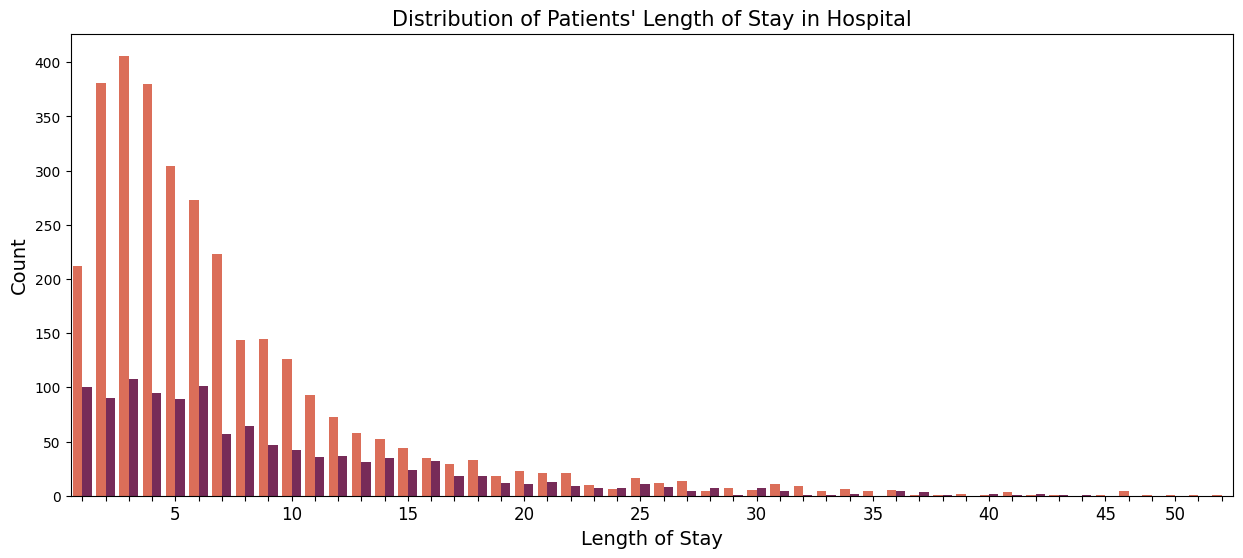

In [15]:
plt.figure(figsize=(15, 6))
sns.countplot(data=data, x="Length_of_stay", hue="Death", palette="rocket_r", legend=False)

# Get current axis
ax = plt.gca()

labels = [label.get_text() for label in ax.get_xticklabels()]
positions = ax.get_xticks()

start_pos = next(pos for pos, label in zip(positions, labels) if int(label) >= 1)

# Adjust labels to show every 5th starting from 1,
new_labels = ['' if int(label) % 5 != 0 else label for label in labels]
ax.set_xticklabels(new_labels, fontsize=12)  # Adjust fontsize as needed
ax.set_xlabel("Length of Stay", fontsize=14)
ax.set_ylabel("Count", fontsize=14)
plt.title("Distribution of Patients' Length of Stay in Hospital", fontsize=15)
plt.show()


<Axes: title={'center': 'Deaths by Severity - probability distribution'}, xlabel='Length_of_stay', ylabel='Count'>

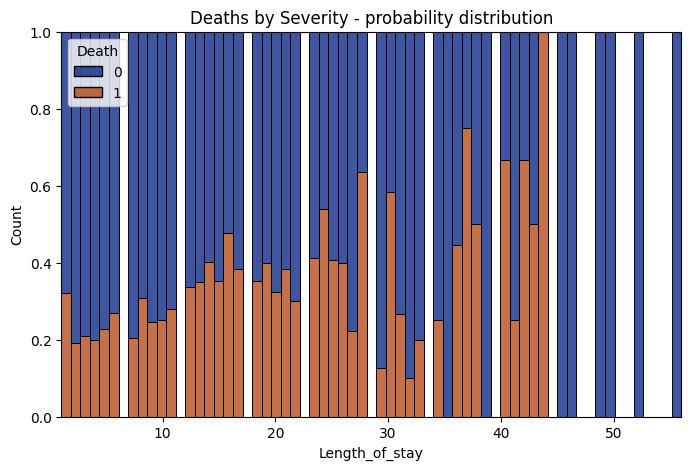

In [17]:
plt.figure(figsize=(8,5))
plt.title('Deaths by Severity - probability distribution')
sns.histplot(x='Length_of_stay', hue='Death',multiple="fill", data=data, palette="dark")

<Axes: title={'center': 'Deaths by Length of stay - probability distribution'}, xlabel='Length_of_stay', ylabel='Count'>

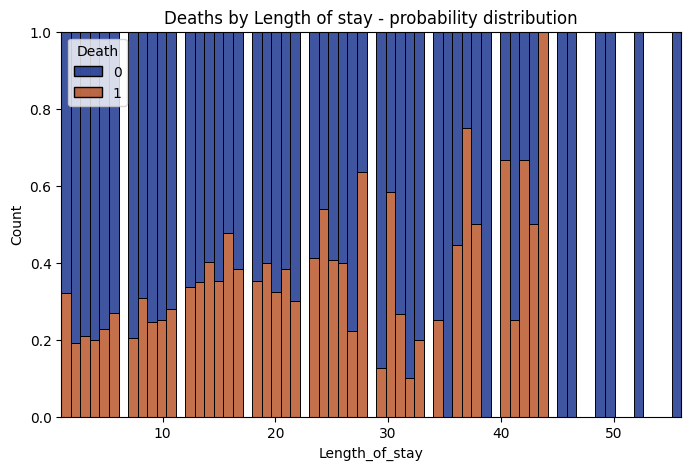

In [19]:
plt.figure(figsize=(8,5))
plt.title('Deaths by Length of stay - probability distribution')
sns.histplot(x='Length_of_stay', hue='Death',multiple="fill", data=data, palette="dark")

<Axes: xlabel='Length_of_stay', ylabel='CRP'>

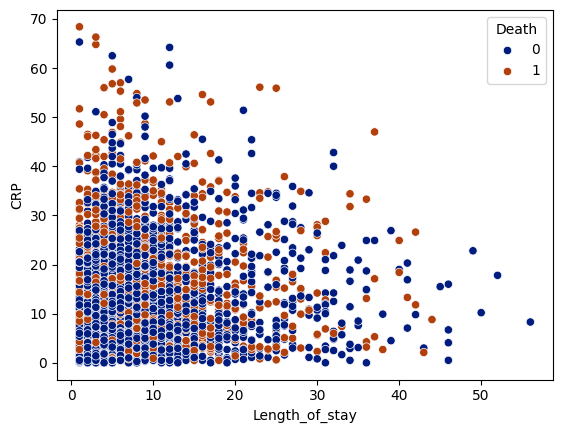

In [20]:
sns.scatterplot(x="Length_of_stay", y="CRP", hue="Death", data=data, palette="dark")

# Vizualizácia vplyvu vybraných atribútov na dĺžku hospitalizácie pacientov s Covidom-19

# FEATURE IMPORTANCE

In [21]:
numeric_features = data.columns[data.nunique() > 10]
numeric_features = numeric_features.drop("Severity")

print("Columnns that contain more than 10 values:\n", numeric_features)
print("Number of nuemrical features:", numeric_features.size)

Columnns that contain more than 10 values:
 Index(['Age_number', 'Oxygen_sat', 'Temperature', 'Mean_art_press', 'Ddimer',
       'Platelets', 'Inter_norm_ratio', 'Blood_urea_nitr', 'Creatinine',
       'Sodium', 'Glucose', 'AST', 'ALT', 'White_blood_cells', 'Lympho',
       'Ferritin', 'CRP', 'Troponin', 'Length_of_stay'],
      dtype='object')
Number of nuemrical features: 19


In [22]:
categorical_features = data.columns[data.nunique() <=4]
categorical_features = categorical_features.drop("Death")
print("Columnns that contain less than 10 values:\n", categorical_features)
print("Number of categorical features:", categorical_features.size)

Columnns that contain less than 10 values:
 Index(['Derivation cohort', 'Black', 'White', 'Asian', 'Latino',
       'Myocardial_infarction', 'Per_vascular_dis', 'Cong_heart_failure',
       'Cardiovascular_dis', 'Dementia', 'Chronic_obst_pulm_dis',
       'Diabetes_mel_complicated', 'Diabetes_mel_simple', 'Renal_dis',
       'All_CNS', 'Pure_CNS', 'Stroke', 'Seizure', 'OldSyncope',
       'Other_neuro_dis', 'Other_brain_lesions', 'Age_category', 'PltsScore',
       'CrtnScore'],
      dtype='object')
Number of categorical features: 24


# Log transformácia numerických atribútov kvôli štatistickým testom

### Výber numerických atribútov

In [23]:
#show only column names with more than 2 unique values, discarding all boolean ones.
cols = ((data.dtypes != 'object') & (data.nunique() > 2))
cols = cols.drop(['Severity', 'CrtnScore','PltsScore','Age_category', "Per_vascular_dis"]) #drop items that show categories, scores, etc.

selectedColumns = list(cols[cols].index)
print(selectedColumns)
print(len(selectedColumns))

['Age_number', 'Oxygen_sat', 'Temperature', 'Mean_art_press', 'Ddimer', 'Platelets', 'Inter_norm_ratio', 'Blood_urea_nitr', 'Creatinine', 'Sodium', 'Glucose', 'AST', 'ALT', 'White_blood_cells', 'Lympho', 'Ferritin', 'CRP', 'Troponin', 'Length_of_stay']
19


## 2. Log transformation

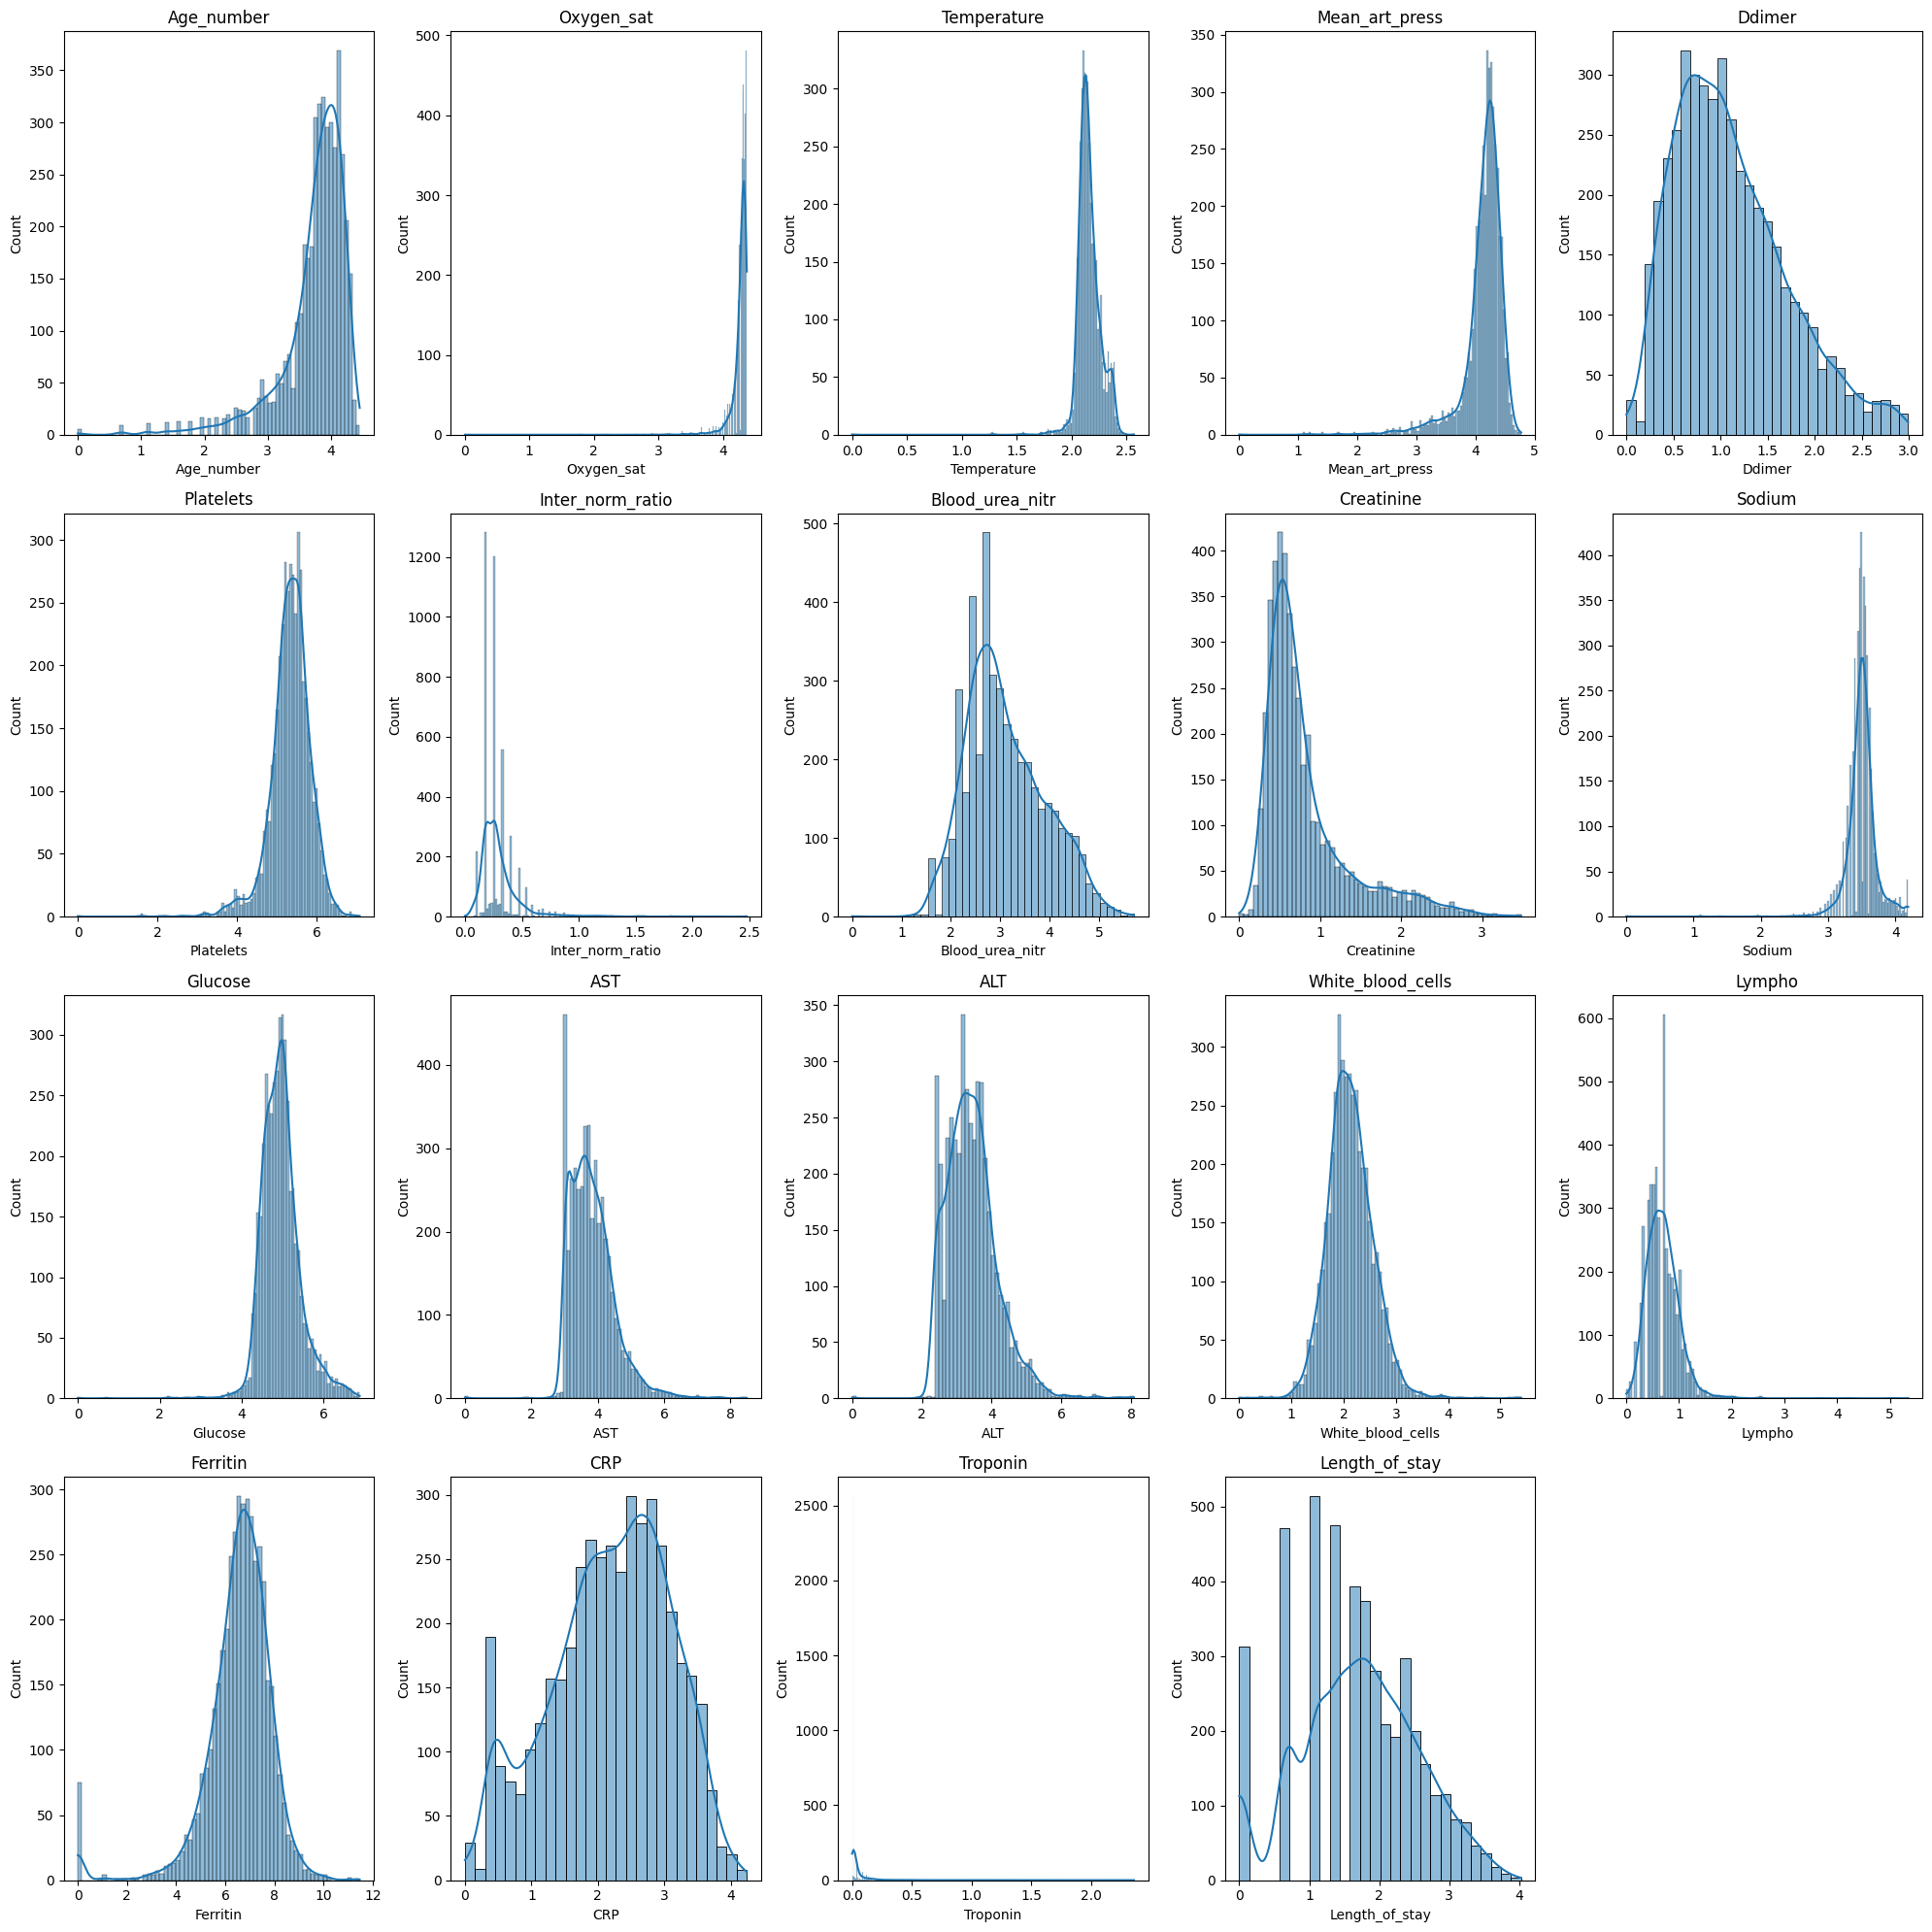

In [24]:
# Ensure all values are positive
data_copy[selectedColumns] = data_copy[selectedColumns] + 1 - data_copy[selectedColumns].min()

# Apply log transformation
data_copy[selectedColumns] = np.log(data_copy[selectedColumns])

num_plots_in_row = 5
num_rows = (len(selectedColumns) + num_plots_in_row - 1) // num_plots_in_row
fig, axes = plt.subplots(nrows=num_rows, ncols=num_plots_in_row, figsize=(20, 5 * num_rows))

# Flatten the axes if there is more than one row
axes = axes.flatten()

# Plot the distribution of each numeric column
for i, column in enumerate(selectedColumns):
    sns.histplot(data_copy[column], kde=True, ax=axes[i])
    axes[i].set_title(column)

# Remove any empty subplots
for j in range(len(selectedColumns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Spearmanov koeficient

<ipython-input-26-8677dde43e87>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=positive_correlations_sorted.head(n_top_features), y=positive_correlations_sorted.head(n_top_features).index, palette='coolwarm')
<ipython-input-26-8677dde43e87>:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=negative_correlations_sorted.head(n_top_features), y=negative_correlations_sorted.head(n_top_features).index, palette='coolwarm')


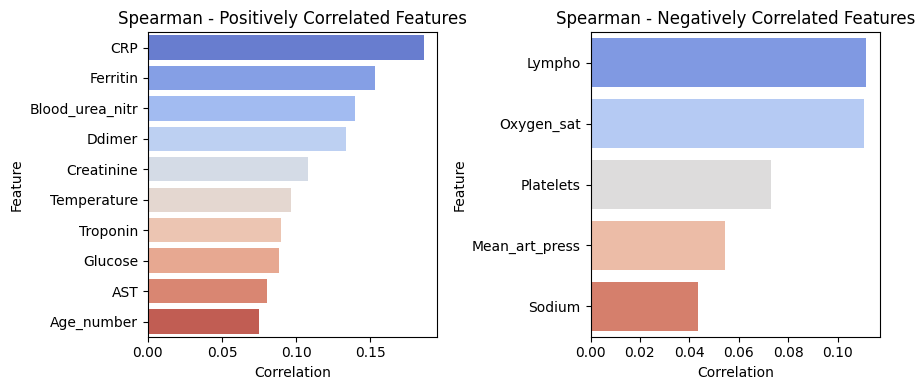

In [26]:
# Specify the target variable
target_feature = 'Length_of_stay'

# Calculate Spearman correlation coefficients with the target variable
corr_with_target = data_copy[numeric_features].corr(method='spearman')[target_feature].drop(target_feature)

# Split correlations into positive and negative
positive_correlations = corr_with_target[corr_with_target > 0]
negative_correlations = corr_with_target[corr_with_target < 0]

# Sort the correlations by their absolute values in descending order
positive_correlations_sorted = positive_correlations.sort_values(ascending=False)
negative_correlations_sorted = negative_correlations.abs().sort_values(ascending=False)

# Extract the top correlated features (both positively and negatively)
n_top_features = 10

# Plot the most positively correlated features
plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
sns.barplot(x=positive_correlations_sorted.head(n_top_features), y=positive_correlations_sorted.head(n_top_features).index, palette='coolwarm')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.title(f'Spearman - Positively Correlated Features')

# Plot the most negatively correlated features
plt.subplot(1, 2, 2)
sns.barplot(x=negative_correlations_sorted.head(n_top_features), y=negative_correlations_sorted.head(n_top_features).index, palette='coolwarm')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.title(f'Spearman - Negatively Correlated Features')

plt.tight_layout()
plt.show()

## Kendallov koeficient pre zistenie vplyvu kategorických atr. na numerický

<ipython-input-27-a720fc0b1acb>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=positive_correlations_sorted.head(n_top_features), y=positive_correlations_sorted.head(n_top_features).index, palette='coolwarm')
<ipython-input-27-a720fc0b1acb>:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=negative_correlations_sorted.head(n_top_features), y=negative_correlations_sorted.head(n_top_features).index, palette='coolwarm')


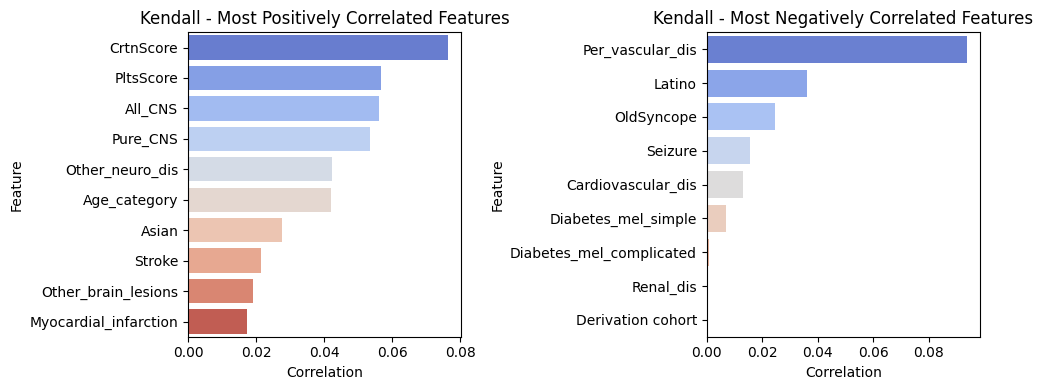

In [27]:
target_feature = 'Length_of_stay'
# Calculate Kendall's tau correlation coefficients with the 'LOS' target variable
corr_with_target = data_copy[categorical_features].apply(lambda x: x.corr(data[target_feature], method='kendall'))

# Split correlations into positive and negative
positive_correlations = corr_with_target[corr_with_target > 0]
negative_correlations = corr_with_target[corr_with_target < 0]

# Sort the correlations by their absolute values in descending order
positive_correlations_sorted = positive_correlations.sort_values(ascending=False)
negative_correlations_sorted = negative_correlations.abs().sort_values(ascending=False)

# Extract the top correlated features (both positively and negatively)
n_top_features = 10

# Plot the most positively correlated features
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.barplot(x=positive_correlations_sorted.head(n_top_features), y=positive_correlations_sorted.head(n_top_features).index, palette='coolwarm')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.title(f'Kendall - Most Positively Correlated Features')

# Plot the most negatively correlated features
plt.subplot(1, 2, 2)
sns.barplot(x=negative_correlations_sorted.head(n_top_features), y=negative_correlations_sorted.head(n_top_features).index, palette='coolwarm')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.title(f'Kendall - Most Negatively Correlated Features')

plt.tight_layout()
plt.show()


## ANOVA pre vplyv kategorických atr. na numerický

ANOVA Test Results:
Feature		P-Value
Other_neuro_dis		3.2790339584769583e-26
PltsScore		3.6287634267628937e-08
All_CNS		2.4553261186956334e-05
Pure_CNS		4.6828105306529196e-05
Per_vascular_dis		5.9656771438835215e-05
Age_category		0.0005573884665604037
CrtnScore		0.0008770322662744916
Other_brain_lesions		0.002888356989851421
Cardiovascular_dis		0.04161157406524826
Derivation cohort		0.0675623472909275
Dementia		0.07540463116956961
Stroke		0.13232572176302487
Asian		0.20193357098309225
Chronic_obst_pulm_dis		0.23204654023644228
Black		0.3249187694692508
Cong_heart_failure		0.326687755129657
Latino		0.49366764203264435
Myocardial_infarction		0.5985742991032355
Diabetes_mel_complicated		0.7971499156618297
Diabetes_mel_simple		0.8309121736861314
Renal_dis		0.8391713019504481
White		0.8692833534164772
Seizure		0.8843599641757115
OldSyncope		0.9986214412922338


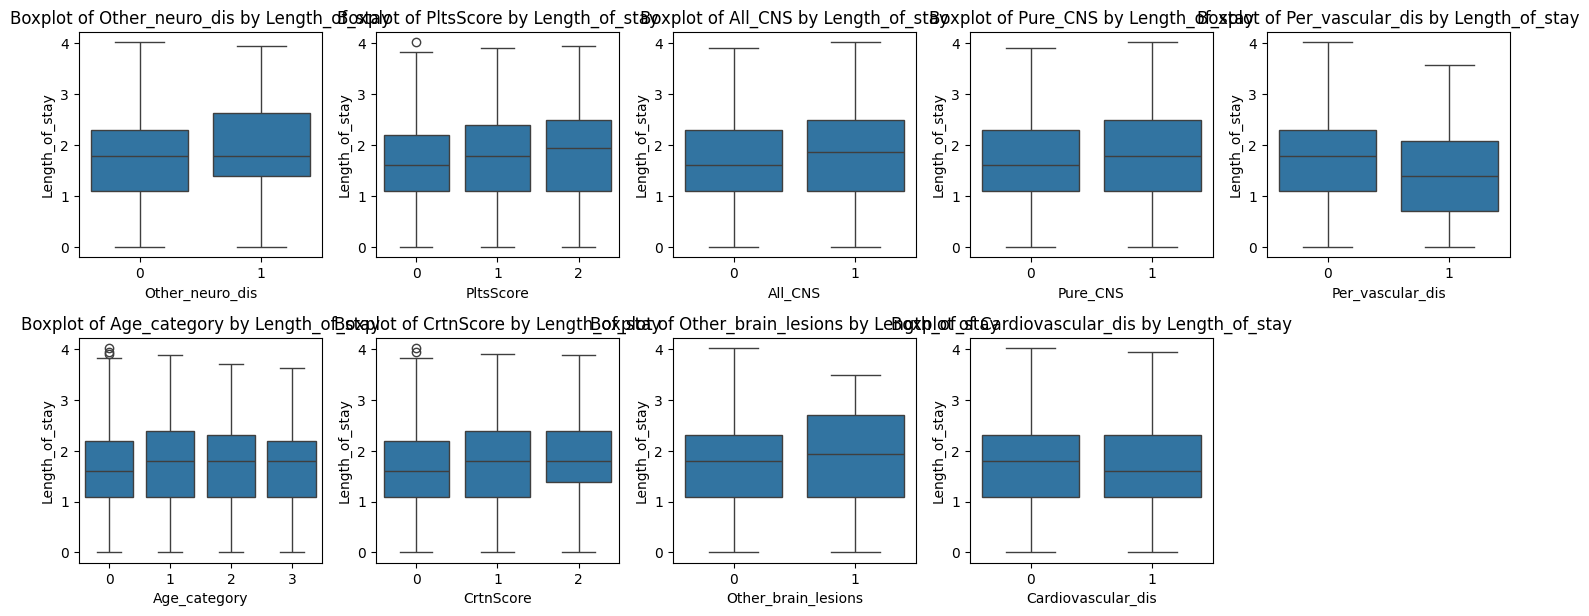

In [28]:
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder

df = pd.DataFrame(data_copy)

# Perform ANOVA test for numeric features
f_stat, p_values_anova = f_classif(df[categorical_features], df['Length_of_stay'])

# Display p-values in ascending order
print("ANOVA Test Results:")
print("Feature\t\tP-Value")
sorted_p_values_anova = sorted(zip(categorical_features, p_values_anova), key=lambda x: x[1])
for feature, p_value_anova in sorted_p_values_anova:
    print(f"{feature}\t\t{p_value_anova}")

# Visualize boxplots for significant features
significant_features = [feature for feature, p_value in sorted_p_values_anova if p_value < 0.05]

# Create subplots for boxplots
plt.figure(figsize=(15, 15))
for i, feature in enumerate(significant_features, 1):
    plt.subplot(5, 5, i)  # 2 rows, 5 columns
    sns.boxplot(y='Length_of_stay', x=feature, data=df)
    plt.title(f'Boxplot of {feature} by Length_of_stay')
    plt.xlabel(feature)
    plt.ylabel('Length_of_stay')
plt.tight_layout()
plt.show()


ANOVA Test Results:
Feature		P-Value
Other_neuro_dis		3.2790339584769583e-26
PltsScore		3.6287634267628937e-08
All_CNS		2.4553261186956334e-05
Pure_CNS		4.6828105306529196e-05
Per_vascular_dis		5.9656771438835215e-05
Age_category		0.0005573884665604037
CrtnScore		0.0008770322662744916
Other_brain_lesions		0.002888356989851421
Cardiovascular_dis		0.04161157406524826
Derivation cohort		0.0675623472909275
Dementia		0.07540463116956961
Stroke		0.13232572176302487
Asian		0.20193357098309225
Chronic_obst_pulm_dis		0.23204654023644228
Black		0.3249187694692508
Cong_heart_failure		0.326687755129657
Latino		0.49366764203264435
Myocardial_infarction		0.5985742991032355
Diabetes_mel_complicated		0.7971499156618297
Diabetes_mel_simple		0.8309121736861314
Renal_dis		0.8391713019504481
White		0.8692833534164772
Seizure		0.8843599641757115
OldSyncope		0.9986214412922338


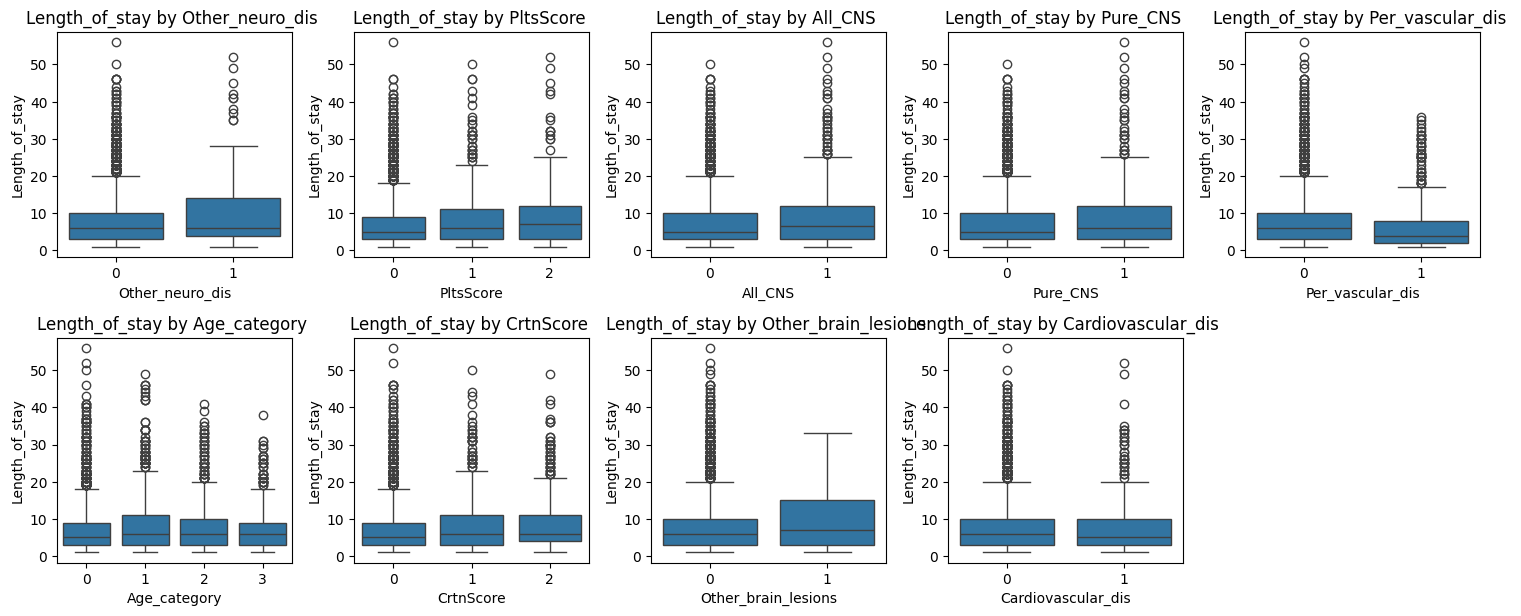

In [29]:
df = pd.DataFrame(data)

# Perform ANOVA test for binary categorical features against 'Length_of_stay'
f_stat, p_values_anova = f_classif(df[categorical_features], df['Length_of_stay'])

# Display p-values in ascending order
print("ANOVA Test Results:")
print("Feature\t\tP-Value")
sorted_p_values_anova = sorted(zip(categorical_features, p_values_anova), key=lambda x: x[1])
for feature, p_value_anova in sorted_p_values_anova:
    print(f"{feature}\t\t{p_value_anova}")

significant_features = [feature for feature, p_value in sorted_p_values_anova if p_value < 0.05]

# Create subplots for boxplots
plt.figure(figsize=(15, 15))
for i, feature in enumerate(significant_features, 1):
    plt.subplot(5, 5, i)
    sns.boxplot(y='Length_of_stay', x=feature, data=df,)
    plt.title(f'Length_of_stay by {feature} ')
    plt.xlabel(feature)
    plt.ylabel('Length_of_stay')
plt.tight_layout()
plt.show()


<ipython-input-30-a01a829c5654>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='Length_of_stay', x=feature, data=df, palette="coolwarm",  ax=axes[i])
<ipython-input-30-a01a829c5654>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='Length_of_stay', x=feature, data=df, palette="coolwarm",  ax=axes[i])
<ipython-input-30-a01a829c5654>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='Length_of_stay', x=feature, data=df, palette="coolwarm",  ax=axes[i])
<ipython-input-30-a01a829c5654>:10: FutureWarning: 

Passing `palette` without ass

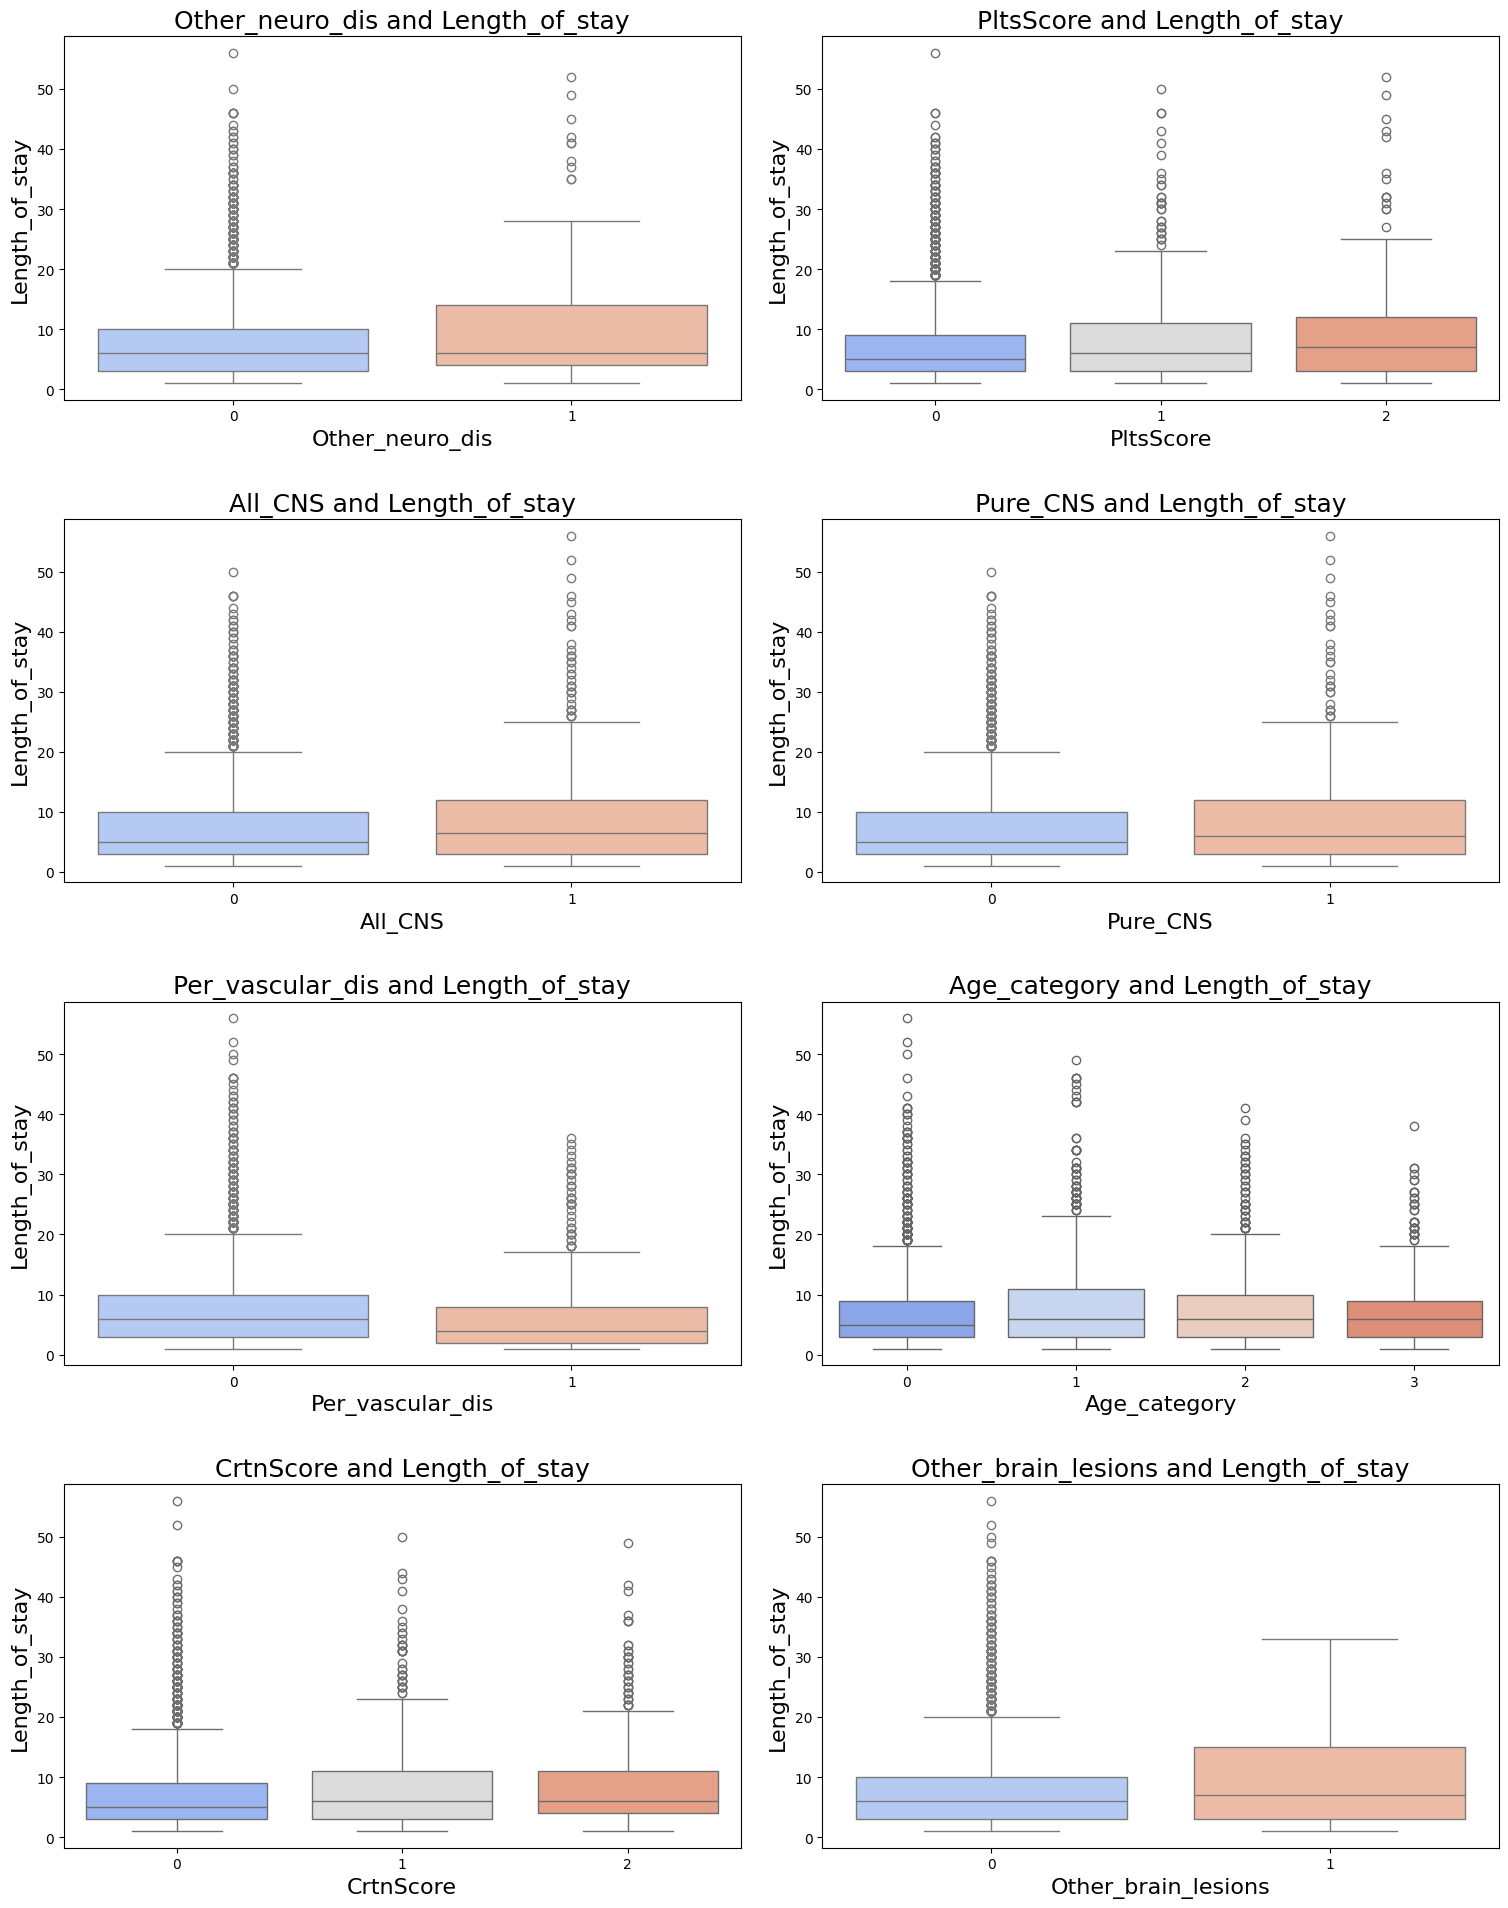

In [30]:
top_8_features = significant_features[:8]

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 20))
axes = axes.flatten()

# Iterate over the top 8 significant features and create boxplots
for i, feature in enumerate(top_8_features):
    sns.boxplot(y='Length_of_stay', x=feature, data=df, palette="coolwarm",  ax=axes[i])
    axes[i].set_title(f'{feature} and Length_of_stay', fontsize=18)
    axes[i].set_xlabel(feature, fontsize=16)
    axes[i].set_ylabel('Length_of_stay', fontsize=16)


plt.tight_layout(pad=4.0, h_pad=3.0, w_pad=2.0)

plt.show()


In [31]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5).fit(data[numeric_features], data['Length_of_stay'])
important_features = [feature for feature, coef in zip(numeric_features, lasso.coef_) if coef != 0]
print('Important features:', important_features)


Important features: ['Platelets', 'Ferritin', 'Length_of_stay']


In [32]:
X = data.drop(columns=["Death","Severity","Length_of_stay"])

y = data["Length_of_stay"]

In [33]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Splitting data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creating and fitting the Lasso Regression model
lasso = Lasso(alpha=0.1)  # Alpha is the regularization strength
lasso.fit(X_train, y_train)

# Making predictions
y_pred = lasso.predict(X_test)

# Calculating Mean Squared Error (MSE) on test set
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

# Get the coefficients and corresponding feature names
coefficients = lasso.coef_
feature_names = [f'Feature {i}' for i in range(X.shape[1])]


Mean Squared Error: 40.90852122530337


In [34]:
feature_names=X.columns

### Najlepšie alpha pre lasso regresiu

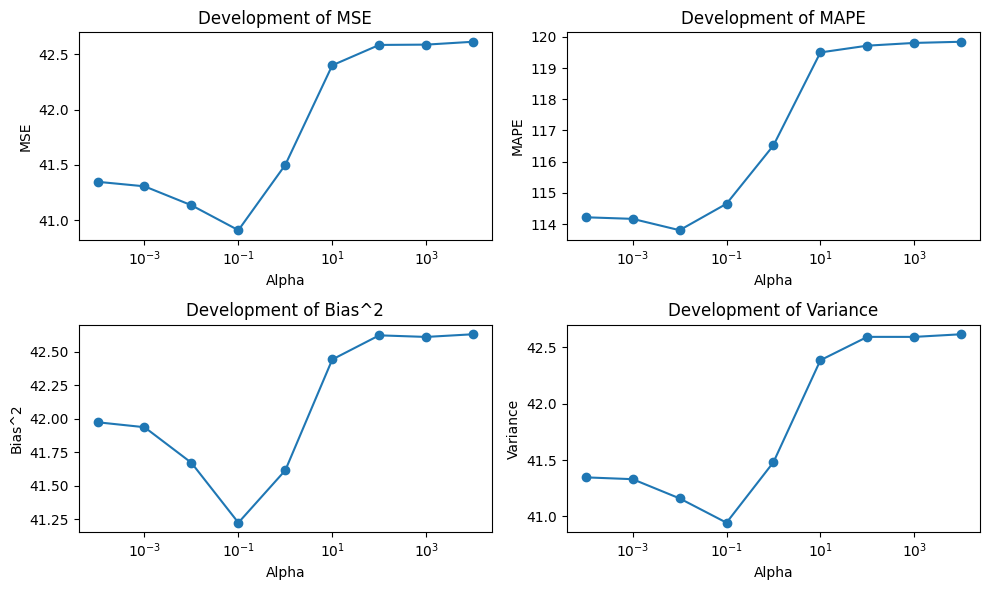

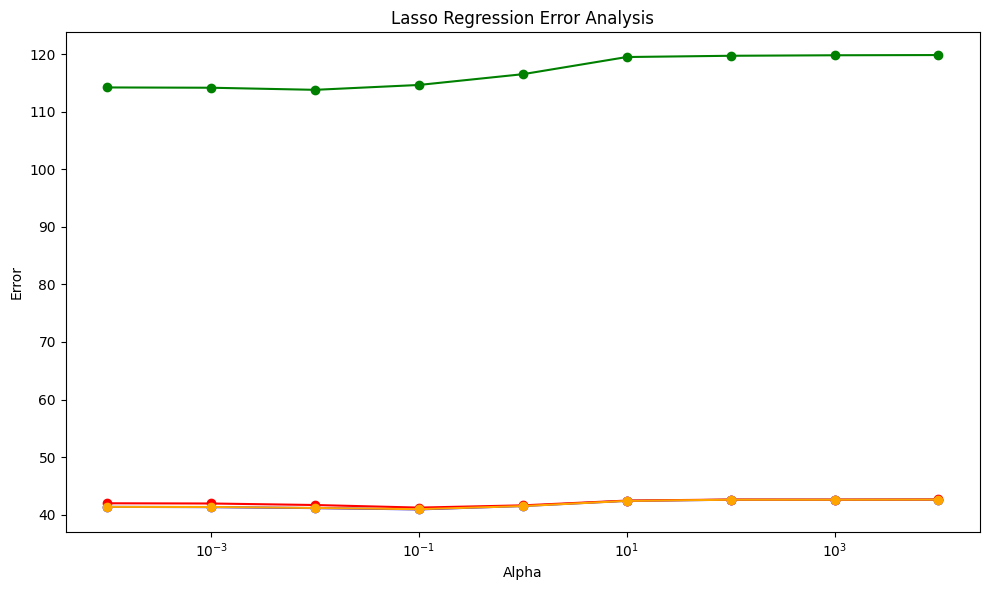

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error
from mlxtend.evaluate import bias_variance_decomp

X = data.drop(columns=["Death","Severity","Length_of_stay"]).values
y = data['Length_of_stay'].values

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define a range of alpha values to be tested
alphas = np.logspace(-4, 4, 9)

# Create lists to store results
mse_values = []
mape_values = []
bias_squared_values = []
variance_values = []

# Iterate over alpha values
for alpha in alphas:
    # Fit Lasso regression
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train, y_train)

    # Make predictions
    y_pred = lasso.predict(X_test)

    # Calculate performance metrics
    mse = mean_squared_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100


    # Bias-Variance Decomposition
    mse_train = mean_squared_error(y_train, lasso.predict(X_train))
    bias_squared, variance, noise = bias_variance_decomp(lasso, X_train, y_train, X_test, y_test, loss='mse', num_rounds=100, random_seed=42)

    # Append results to lists
    mse_values.append(mse)
    mape_values.append(mape)
    bias_squared_values.append(bias_squared)
    variance_values.append(variance)

# Plot results
plt.figure(figsize=(10, 6))

plt.subplot(2, 2, 1)
plt.plot(alphas, mse_values, marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('MSE')
plt.title('Development of MSE')

plt.subplot(2, 2, 2)
plt.plot(alphas, mape_values, marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('MAPE')
plt.title('Development of MAPE')

plt.subplot(2, 2, 3)
plt.plot(alphas, bias_squared_values, marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Bias^2')
plt.title('Development of Bias^2')

plt.subplot(2, 2, 4)
plt.plot(alphas, variance_values, marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Variance')
plt.title('Development of Variance')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))


plt.plot(alphas, mse_values, marker='o', color='blue', label = "MSE")
plt.plot(alphas, mape_values, marker='o', color= 'green', label = "MAPE")
plt.plot(alphas, bias_squared_values, marker='o', color= 'red', label = "Bias^2")
plt.plot(alphas, variance_values, marker='o', color = 'orange', label = "Variance")

plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Error')
plt.title('Lasso Regression Error Analysis')
plt.tight_layout()
plt.show()

## LASSO REGRESSION with ALpha 0.1

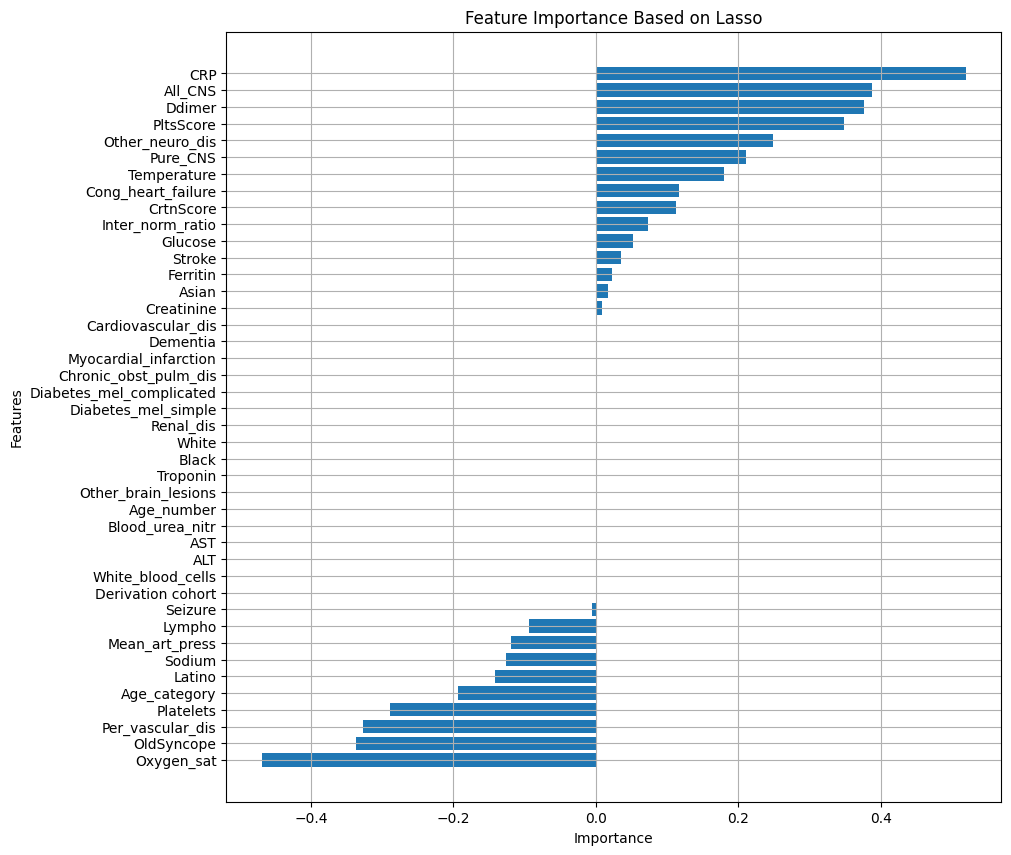

In [ ]:
X = data.drop(columns=["Death","Severity","Length_of_stay"])
y = data['Length_of_stay']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizing the features if not already done
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

# Getting the coefficients
coefficients = lasso.coef_

# Sort feature importance coefficients
sorted_indices = np.argsort(coefficients)

# Get sorted feature names and importance values
sorted_features = np.array(X_train.columns)[sorted_indices]
sorted_importance = coefficients[sorted_indices]

# Plotting
plt.figure(figsize=(10,10))
plt.barh(sorted_features, sorted_importance)
plt.grid(True)
plt.title("Feature Importance Based on Lasso")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

# Atribút LOS_class - feature importance

In [41]:
data["Length_of_stay"].unique() # 12 different values

array([ 1,  2, 15,  9, 14,  4,  3,  6,  7, 11, 10,  5, 25, 13, 17, 26,  8,
       12, 29, 16, 20, 34, 28, 22, 18, 31, 32, 49, 23, 36, 21, 27, 30, 33,
       19, 56, 24, 39, 43, 35, 42, 45, 37, 38, 41, 40, 46, 50, 44, 52])

Vytvorenie stĺpca LOS_class

In [43]:
labels = [0, 1,2]
data['LOS_class'] = pd.qcut(x=data["Length_of_stay"], q=3, labels=labels, retbins=False)

In [44]:
data['LOS_class'] =pd.to_numeric(data['LOS_class'])

<Axes: xlabel='Length_of_stay', ylabel='count'>

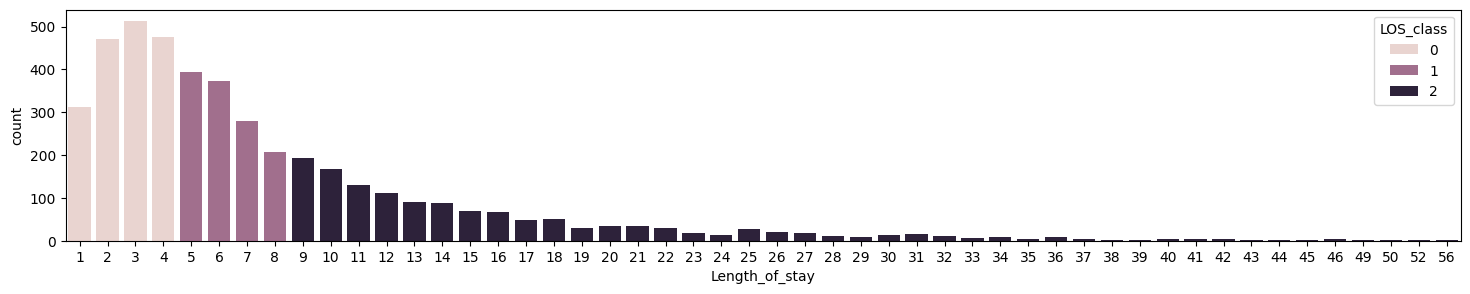

In [46]:
plt.figure(figsize=(18,3))
sns.countplot(x="Length_of_stay", hue="LOS_class",data=data)

<Axes: xlabel='LOS_class', ylabel='count'>

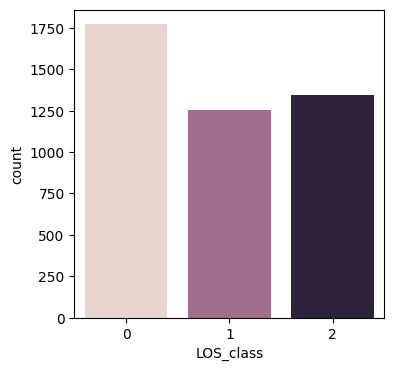

In [47]:
plt.figure(figsize=(4,4))
sns.countplot(x= "LOS_class", data=data, hue="LOS_class", legend = False)

## ANOVA pre vplyv numerických atr. na kategorický

ANOVA Test Results:
Feature		P-Value
Length_of_stay		0.0
CRP		1.1135842477219962e-23
Age_number		2.4917115375526803e-11
Oxygen_sat		1.2684769208470393e-10
Ddimer		2.805988466810203e-10
Creatinine		1.583162010688922e-07
Temperature		4.5391873509486594e-07
Blood_urea_nitr		5.586172666450206e-07
Platelets		2.957765320362888e-06
Ferritin		3.23967550345481e-06
Mean_art_press		5.4727272721560505e-06
Glucose		0.001011553213210126
Inter_norm_ratio		0.002976165557419441
Lympho		0.03306584868124427
Troponin		0.1191507801361752
Sodium		0.4684933246763504
White_blood_cells		0.7423696181710351
ALT		0.9044758135152624
AST		0.9981463547989279


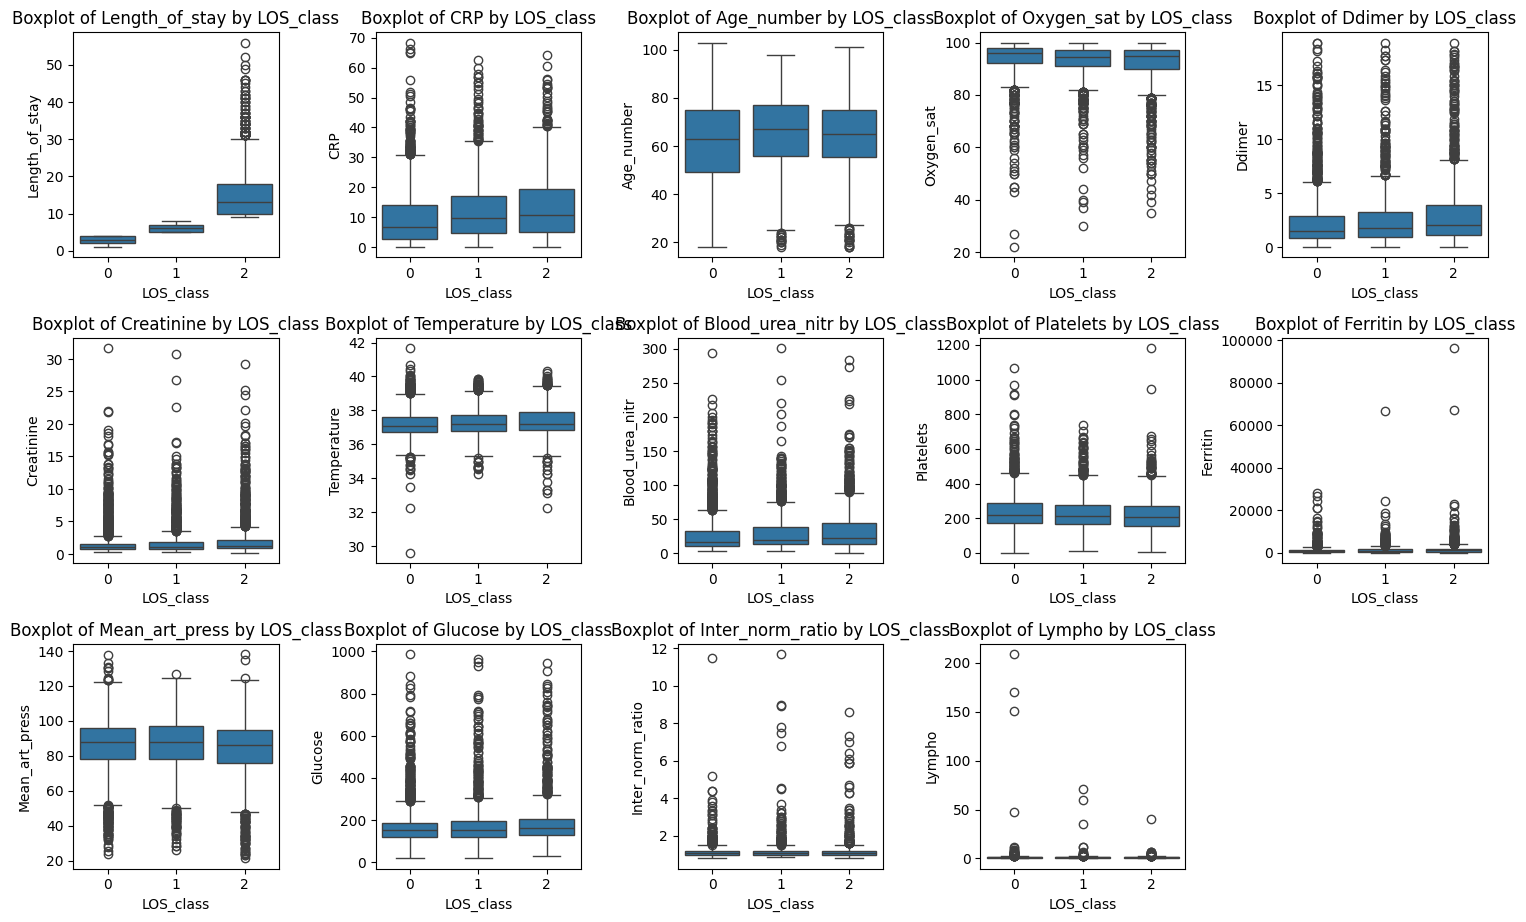

In [48]:
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder

df = pd.DataFrame(data)

# Perform ANOVA test for numeric features
f_stat, p_values_anova = f_classif(df[numeric_features], df['LOS_class'])

# Display p-values in ascending order
print("ANOVA Test Results:")
print("Feature\t\tP-Value")
sorted_p_values_anova = sorted(zip(numeric_features, p_values_anova), key=lambda x: x[1])
for feature, p_value_anova in sorted_p_values_anova:
    print(f"{feature}\t\t{p_value_anova}")

# Visualize boxplots for significant features
significant_features = [feature for feature, p_value in sorted_p_values_anova if p_value < 0.05]

# Create subplots for boxplots
plt.figure(figsize=(15, 15))
for i, feature in enumerate(significant_features, 1):
    plt.subplot(5, 5, i)  # 2 rows, 5 columns
    sns.boxplot(x='LOS_class', y=feature, data=df)
    plt.title(f'Boxplot of {feature} by LOS_class')
    plt.xlabel('LOS_class')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()


## CHI - square test for categorical input and categorical output

In [49]:
categorical_features = data.columns[data.nunique() <=4]

print("Columnns that contain less than 10 values:\n", categorical_features)
print("Number of categorical features:", categorical_features.size)

Columnns that contain less than 10 values:
 Index(['Derivation cohort', 'Death', 'Black', 'White', 'Asian', 'Latino',
       'Myocardial_infarction', 'Per_vascular_dis', 'Cong_heart_failure',
       'Cardiovascular_dis', 'Dementia', 'Chronic_obst_pulm_dis',
       'Diabetes_mel_complicated', 'Diabetes_mel_simple', 'Renal_dis',
       'All_CNS', 'Pure_CNS', 'Stroke', 'Seizure', 'OldSyncope',
       'Other_neuro_dis', 'Other_brain_lesions', 'Age_category', 'PltsScore',
       'CrtnScore', 'LOS_class'],
      dtype='object')
Number of categorical features: 26



Chi-Squared Test Results:
Feature	P-Value
LOS_class	0.0
Other_neuro_dis	3.752922976139127e-24
PltsScore	5.161261821876343e-12
CrtnScore	4.6993733367510405e-06
Age_category	0.00013309900694184686
Pure_CNS	0.000728637266966638
All_CNS	0.0008015620871921241
Per_vascular_dis	0.002806873169050754
Other_brain_lesions	0.0033862707803238856


<ipython-input-51-0a40fa983ccd>:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='P-Value', y='Feature', data=filtered_df, palette='Purples')


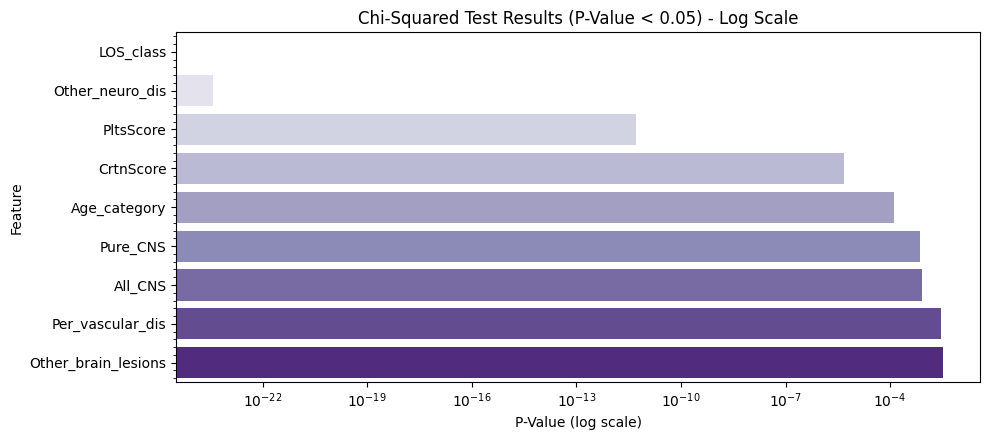

In [51]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder

df = pd.DataFrame(data)

# Encode these categorical features
le = LabelEncoder()
for column in categorical_features:
    if df[column].dtype == 'object' or column in categorical_features:
        df[column] = le.fit_transform(df[column].astype(str))

features_to_test = [col for col in categorical_features if col != 'Death']

# Perform the chi-squared test
chi2_stat, p_values = chi2(df[features_to_test], df['Length_of_stay'])

# Correctly display p-values in ascending order and filter for p < 0.05
sorted_features_p_values = sorted(zip(features_to_test, p_values), key=lambda x: x[1])
print("\nChi-Squared Test Results:\nFeature\tP-Value")
for feature, p_value in sorted_features_p_values:
    if p_value < 0.05:
        print(f"{feature}\t{p_value}")

# Filter for p-values < 0.05
filtered_p_values = [(feature, p_value) for feature, p_value in sorted_features_p_values if p_value < 0.05]
filtered_df = pd.DataFrame(filtered_p_values, columns=['Feature', 'P-Value'])

# Adjust the visualization with a log scale
plt.figure(figsize=(10, len(filtered_p_values) * 0.5))
sns.barplot(x='P-Value', y='Feature', data=filtered_df, palette='Purples')

# Set the x-axis to log scale to better visualize values close to 0
plt.xscale('log')

plt.minorticks_on()
plt.tick_params(axis='x', which='minor', bottom=False)
plt.xlabel('P-Value (log scale)')
plt.ylabel('Feature')
plt.title('Chi-Squared Test Results (P-Value < 0.05) - Log Scale')
plt.tight_layout()
plt.show()


# Normalizácia pre modelovanie

### Výber numerických atribútov na normalizáciu, okrem cieľovej premennej LOS !

In [94]:
#show only column names with more than 2 unique values, discarding all boolean ones.
cols = ((data.dtypes != 'object') & (data.nunique() > 2))
cols = cols.drop(['Length_of_stay', 'CrtnScore','PltsScore','Age_category','Per_vascular_dis']) #drop items that show categories, scores, etc.

selectedColumns = list(cols[cols].index)
print(selectedColumns)
print(len(selectedColumns))

['Severity', 'Age_number', 'Oxygen_sat', 'Temperature', 'Mean_art_press', 'Ddimer', 'Platelets', 'Inter_norm_ratio', 'Blood_urea_nitr', 'Creatinine', 'Sodium', 'Glucose', 'AST', 'ALT', 'White_blood_cells', 'Lympho', 'Ferritin', 'CRP', 'Troponin']
19


Numeric features distributions

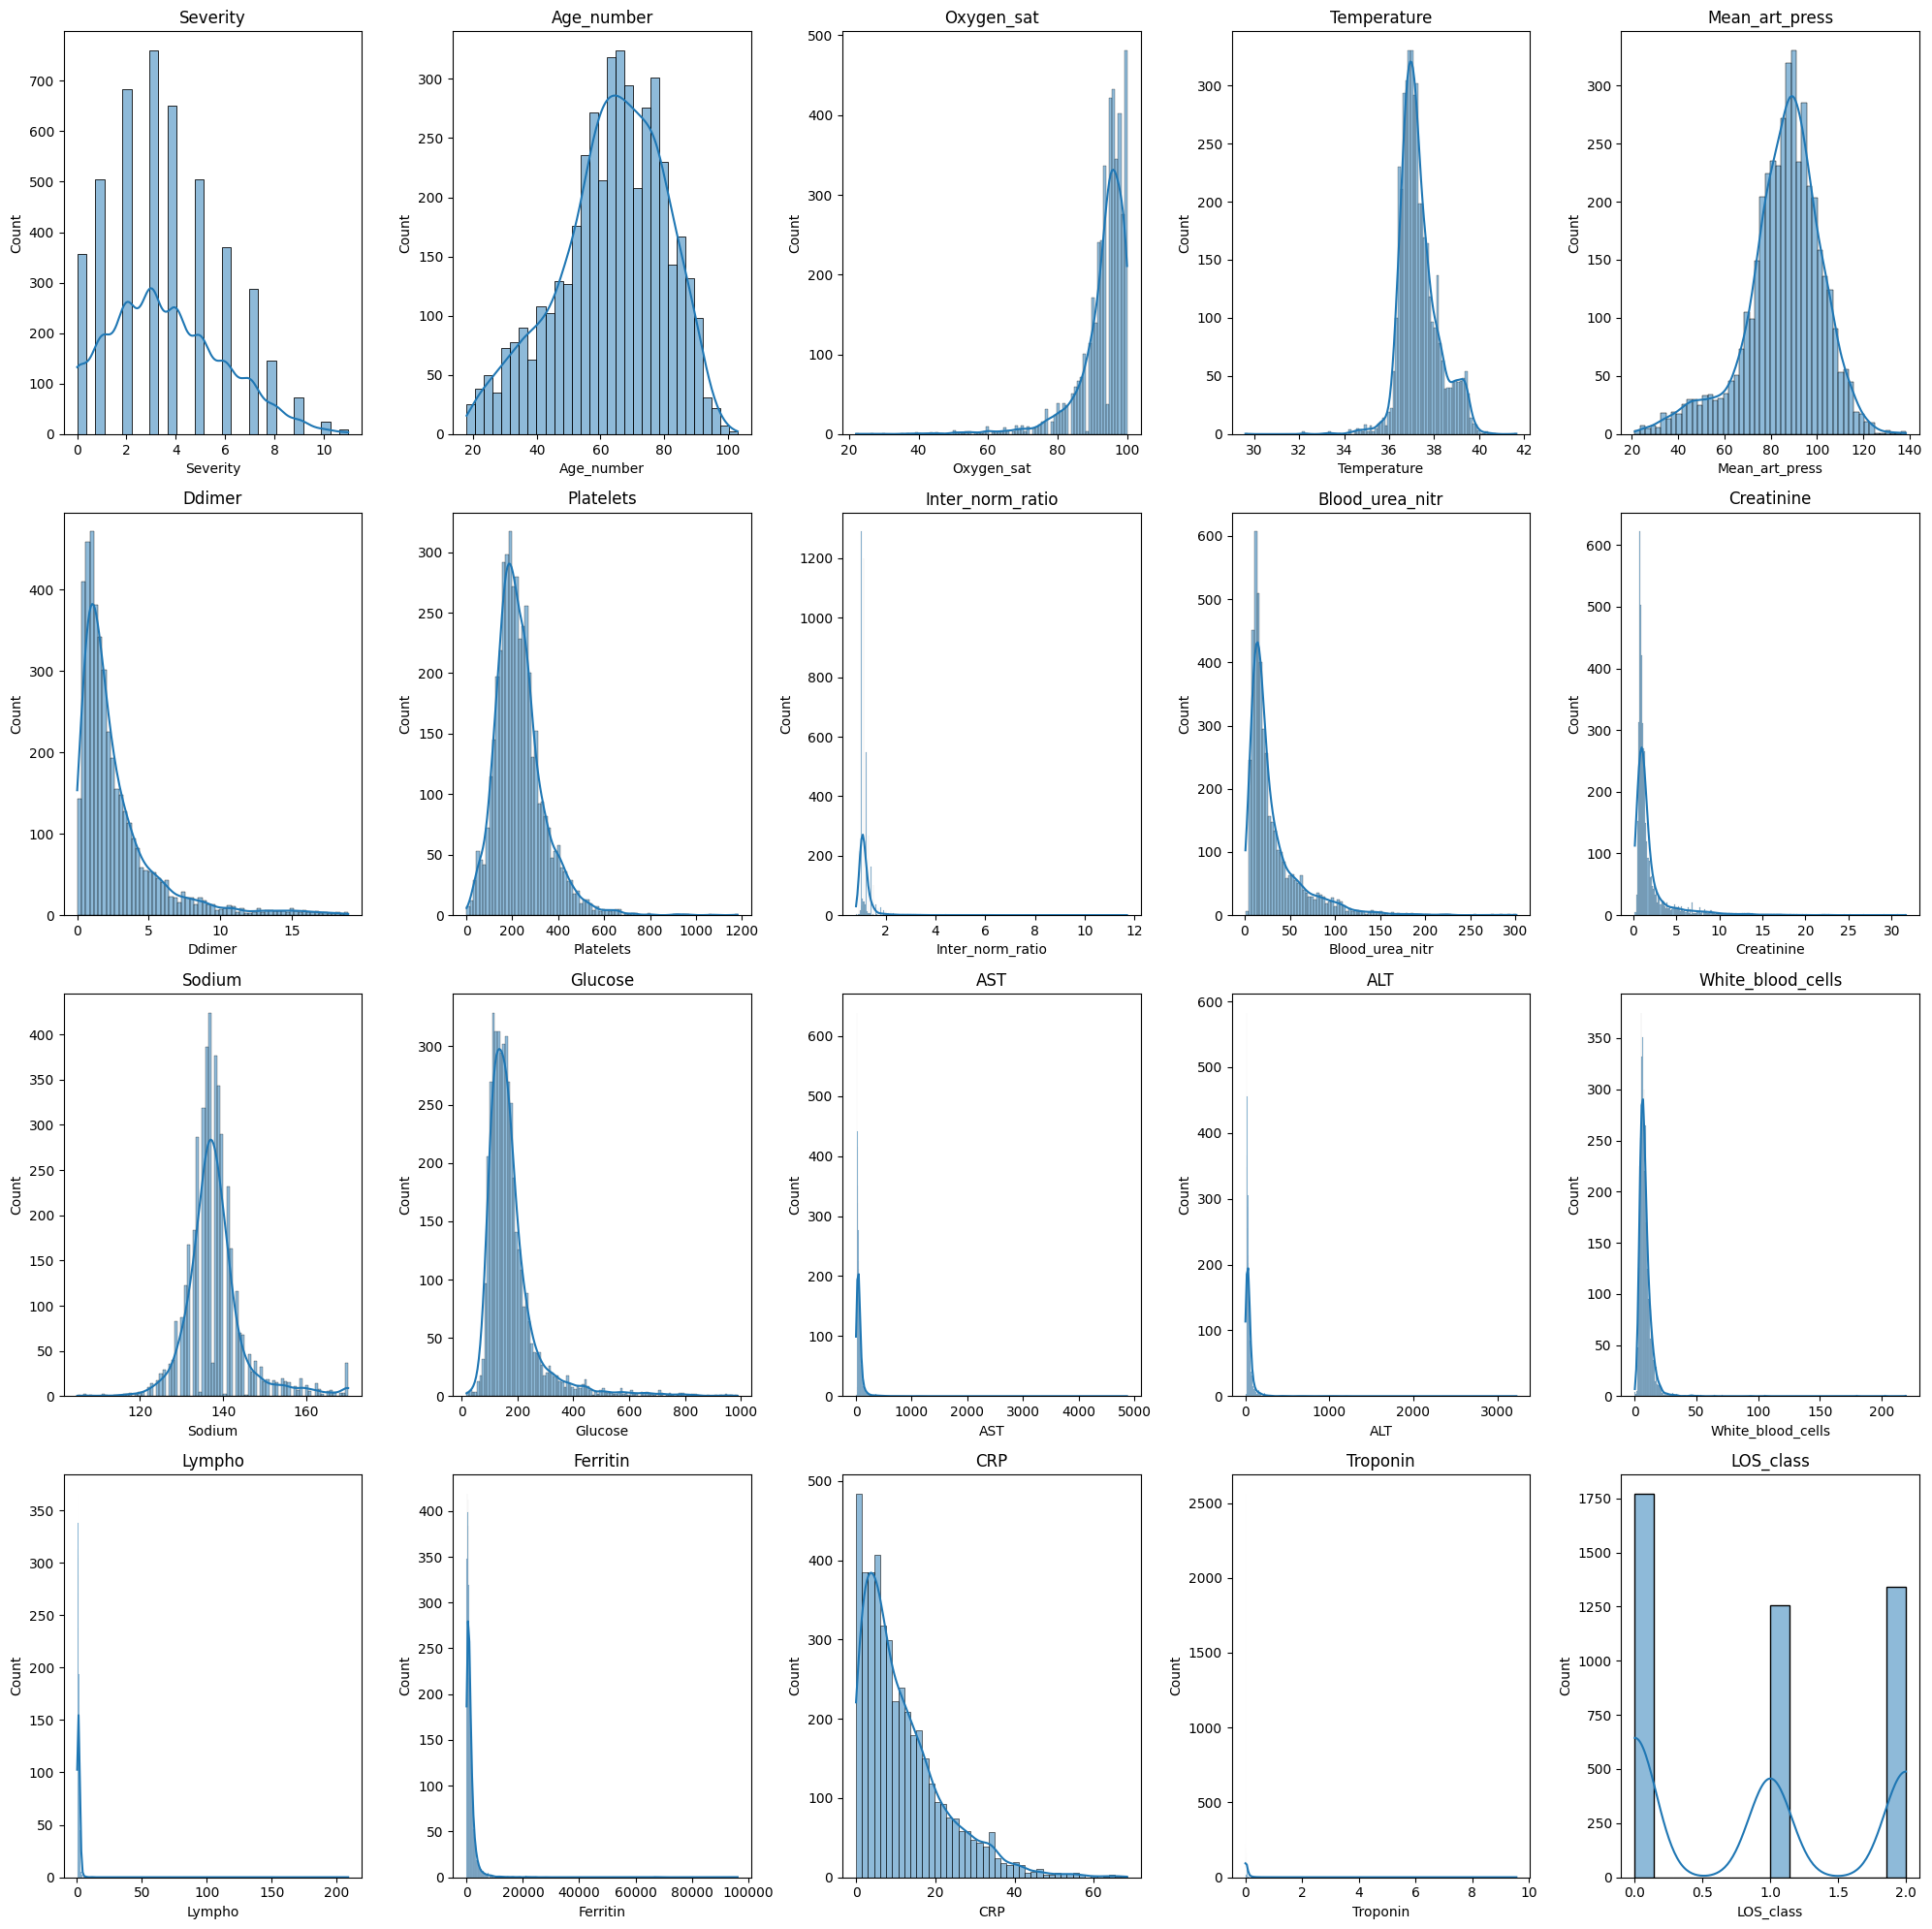

In [53]:
num_plots_in_row = 5
num_rows = (len(selectedColumns) + num_plots_in_row - 1) // num_plots_in_row
fig, axes = plt.subplots(nrows=num_rows, ncols=num_plots_in_row, figsize=(20, 5 * num_rows))

# Flatten the axes if there is more than one row
axes = axes.flatten()

# Plot the distribution of each numeric column
for i, column in enumerate(selectedColumns):
    sns.histplot(data[column], kde=True, ax=axes[i])
    axes[i].set_title(column)

# Remove any empty subplots
for j in range(len(selectedColumns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Standard Scaler

In [95]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
# Select the columns we want to normalize
columns_to_normalize = selectedColumns

# Create a new DataFrame for the columns to normalize
data_to_normalize = data[columns_to_normalize]

# Normalize using Min-Max scaling
standard_scaler = StandardScaler()
data_to_normalize_minmax = standard_scaler.fit_transform(data_to_normalize)

# Update the original DataFrame with the normalized values
data[columns_to_normalize] = data_to_normalize_minmax

data.head(5)

,Derivation cohort,Death,Severity,Black,White,Asian,Latino,Myocardial_infarction,Per_vascular_dis,Cong_heart_failure,...,Sodium,Glucose,AST,ALT,White_blood_cells,Lympho,Ferritin,CRP,Troponin,Length_of_stay
0,1,0,-0.256860,0,0,0,0,0,0,0,...,-0.419506,-0.656093,-0.267768,-0.279221,-0.419794,0.007101,-0.502898,-1.074356,-0.172812,1.0
1,1,1,1.484091,0,1,0,0,0,1,0,...,-0.145350,0.846855,0.147657,-0.118225,0.499551,-0.212384,-0.179776,0.314844,4.074618,2.0
2,1,1,1.484091,0,1,0,0,0,1,1,...,0.265883,-0.567684,-0.225521,-0.243444,-0.350147,-0.172478,-0.273244,2.147803,-0.110307,2.0
3,1,0,2.354566,1,0,0,0,1,0,0,...,-0.830738,-0.033725,-0.141028,-0.252389,-0.684454,-0.172478,-0.204969,0.652494,-0.030041,15.0
4,1,0,1.484091,1,0,0,0,0,0,0,...,1.499581,-0.020131,-0.183275,-0.154002,-0.405865,0.007101,0.114502,-0.003512,-0.172812,9.0


## Vytvorenie pomocných "dummies" atribútov pre kategorické atribúty

In [96]:
# Use pandas get_dummies to create dummy variables for each categorical column
data = pd.get_dummies(data, columns=['CrtnScore', 'PltsScore', 'Age_category', 'Per_vascular_dis'], prefix=['CrtnScore', 'PltsScore', 'AgeScore', 'Per_vascular_dis'])

data.head(5)

,Derivation cohort,Death,Severity,Black,White,Asian,Latino,Myocardial_infarction,Cong_heart_failure,Cardiovascular_dis,...,CrtnScore_2,PltsScore_0,PltsScore_1,PltsScore_2,AgeScore_0,AgeScore_1,AgeScore_2,AgeScore_3,Per_vascular_dis_0,Per_vascular_dis_1
0,1,0,-0.256860,0,0,0,0,0,0,0,...,False,True,False,False,False,False,False,True,True,False
1,1,1,1.484091,0,1,0,0,0,0,0,...,True,True,False,False,False,True,False,False,False,True
2,1,1,1.484091,0,1,0,0,0,1,1,...,True,False,True,False,False,False,False,True,False,True
3,1,0,2.354566,1,0,0,0,1,0,0,...,True,True,False,False,False,False,True,False,True,False
4,1,0,1.484091,1,0,0,0,0,0,0,...,True,False,True,False,False,False,True,False,True,False


In [70]:
data.columns

Index(['Derivation cohort', 'Death', 'Severity', 'Black', 'White', 'Asian',
       'Latino', 'Myocardial_infarction', 'Cong_heart_failure',
       'Cardiovascular_dis', 'Dementia', 'Chronic_obst_pulm_dis',
       'Diabetes_mel_complicated', 'Diabetes_mel_simple', 'Renal_dis',
       'All_CNS', 'Pure_CNS', 'Stroke', 'Seizure', 'OldSyncope',
       'Other_neuro_dis', 'Other_brain_lesions', 'Age_number', 'Oxygen_sat',
       'Temperature', 'Mean_art_press', 'Ddimer', 'Platelets',
       'Inter_norm_ratio', 'Blood_urea_nitr', 'Creatinine', 'Sodium',
       'Glucose', 'AST', 'ALT', 'White_blood_cells', 'Lympho', 'Ferritin',
       'CRP', 'Troponin', 'Length_of_stay', 'CrtnScore_0', 'CrtnScore_1',
       'CrtnScore_2', 'PltsScore_0', 'PltsScore_1', 'PltsScore_2',
       'AgeScore_0', 'AgeScore_1', 'AgeScore_2', 'AgeScore_3',
       'Per_vascular_dis_0', 'Per_vascular_dis_1'],
      dtype='object')

# MODELLING LENGHT OF STAY for SHAP values

### Cieľová trieda - numeric - Length of Stay

In [97]:
X = data.drop(columns=["Death","Severity","Length_of_stay"]) # "LOS_class" !!!!

y = data["Length_of_stay"]

In [98]:
from sklearn.model_selection import train_test_split
train_x, test_x, train_y, test_y = train_test_split(X,y, test_size=0.2, random_state=42)
print("Train_x :",train_x.shape)
print("Test_x :",test_x.shape)
print("Train_y :",train_y.shape)
print("Test_y :",test_y.shape)

Train_x : (3496, 50)
Test_x : (874, 50)
Train_y : (3496,)
Test_y : (874,)


# Všetky modely - porovnanie podľa MAE

In [100]:
# Define a basic sequential model for regression
def create_sequential_model(input_shape):
    model = Sequential([
        Dense(64, activation='relu', input_shape=input_shape),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(), loss='mean_squared_error')
    return model

# Define regression models to test
models = [
    ('LinearRegression', LinearRegression()),
    ('Ridge', Ridge()),
    ('Lasso', Lasso()),
    ('RandomForest', RandomForestRegressor()),
    ('LGBMRegressor', LGBMRegressor()),
    ('SVR', SVR()),
    ('KNN', KNeighborsRegressor()),
    ('XGBRegressor', xgb.XGBRegressor()),
    ('CatBoostRegressor', cb.CatBoostRegressor(verbose=0)),  # verbose=0 to keep the output clean

]

results_table = []

for name, model in models:
    if name == 'SequentialNN':
        # Create and train the Sequential model
        model = create_sequential_model((train_x.shape[1],))
        history = model.fit(train_x, train_y, epochs=10, batch_size=32, verbose=0)
        predictions = model.predict(test_x).flatten()  # Flatten predictions
    else:
        # Train the model
        model.fit(train_x, train_y)
        # Make predictions
        predictions = model.predict(test_x)

    # Calculate metrics
    mae = mean_absolute_error(test_y, predictions)
    mse = mean_squared_error(test_y, predictions)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(test_y, predictions)

    # Store results
    results_table.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape
    })

# Convert results table to a DataFrame for better visualization
results_df = pd.DataFrame(results_table)

# Round the DataFrame to three decimal places
results_df = results_df.round(3)

# Sort the DataFrame based on a chosen metric, for example, MAE, to find the best model
results_df.sort_values(by='MAE', inplace=True)

# Display the DataFrame
print(results_df)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001328 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3965
[LightGBM] [Info] Number of data points in the train set: 3496, number of used features: 49
[LightGBM] [Info] Start training from score 7.732838
               Model    MAE     MSE   RMSE   MAPE
5                SVR  4.197  43.167  6.570  0.761
8  CatBoostRegressor  4.640  41.476  6.440  1.117
1              Ridge  4.654  41.339  6.430  1.145
0   LinearRegression  4.655  41.337  6.429  1.145
4      LGBMRegressor  4.685  42.796  6.542  1.131
3       RandomForest  4.754  42.159  6.493  1.203
2              Lasso  4.802  42.615  6.528  1.198
7       XGBRegressor  4.983  46.119  6.791  1.216
6                KNN  5.024  49.181  7.013  1.151


## SVR

Mean Absolute Error: 4.196729059718295
MSE: 43.16747632472655
RMSE: 6.570196064405274


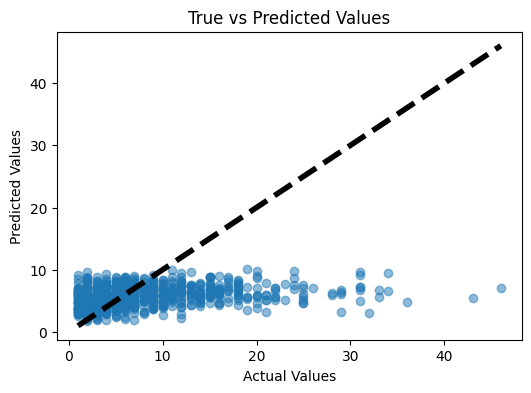

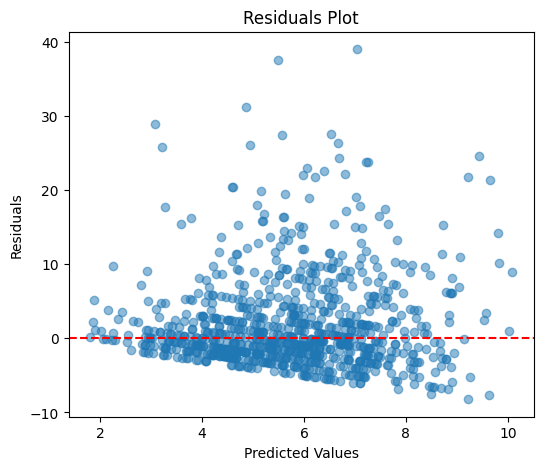

In [99]:
# Create and fit the SVR model
svr = SVR()
svr.fit(train_x, train_y)

# Predictions for the SVR model
y_pred = svr.predict(test_x)

# Evaluate the SVR model in the original scale
mse = mean_squared_error(test_y, y_pred)
mape = mean_absolute_percentage_error(test_y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test_y, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

# Plotting true vs predicted values in original scale
plt.figure(figsize=(6, 4))
plt.scatter(test_y, y_pred, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values")
plt.plot([min(test_y.min(), y_pred.min()), max(test_y.max(), y_pred.max())], [min(test_y.min(), y_pred.min()), max(test_y.max(), y_pred.max())], 'k--', lw=4)
plt.show()

# Plotting residuals in original scale
residuals_original = test_y - y_pred
plt.figure(figsize=(6, 5))
plt.scatter(y_pred, residuals_original, alpha=0.5)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals Plot")
plt.axhline(y=0, color='r', linestyle='--')
plt.show()


## SVR C=1, epsilon=0.2)

Mean Absolute Error: 4.20132132219578
Mean Squared Error: 43.20338612065883


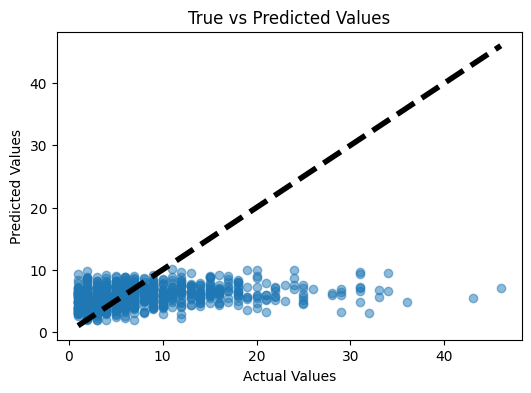

In [117]:
model = SVR(C=1, epsilon=0.2)

# Fit the model
model.fit(train_x, train_y)
y_pred = model.predict(test_x)

# Evaluate the model
print(f"Mean Absolute Error: {mean_absolute_error(test_y, y_pred)}")
print(f"Mean Squared Error: {mean_squared_error(test_y, y_pred)}")

# Plotting true vs predicted values
plt.figure(figsize=(6, 4))
plt.scatter(test_y, y_pred, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values")
# Use min and max from both actual and predicted values for a more accurate line
plt.plot([min(test_y.min(), y_pred.min()), max(test_y.max(), y_pred.max())], [min(test_y.min(), y_pred.min()), max(test_y.max(), y_pred.max())], 'k--', lw=4)
plt.show()


## LGB Regressor

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003044 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3965
[LightGBM] [Info] Number of data points in the train set: 3496, number of used features: 49
[LightGBM] [Info] Start training from score 7.732838
Mean Absolute Error: 4.68501630016009
MSE: 42.79563011702829
RMSE: 6.5418369069419855


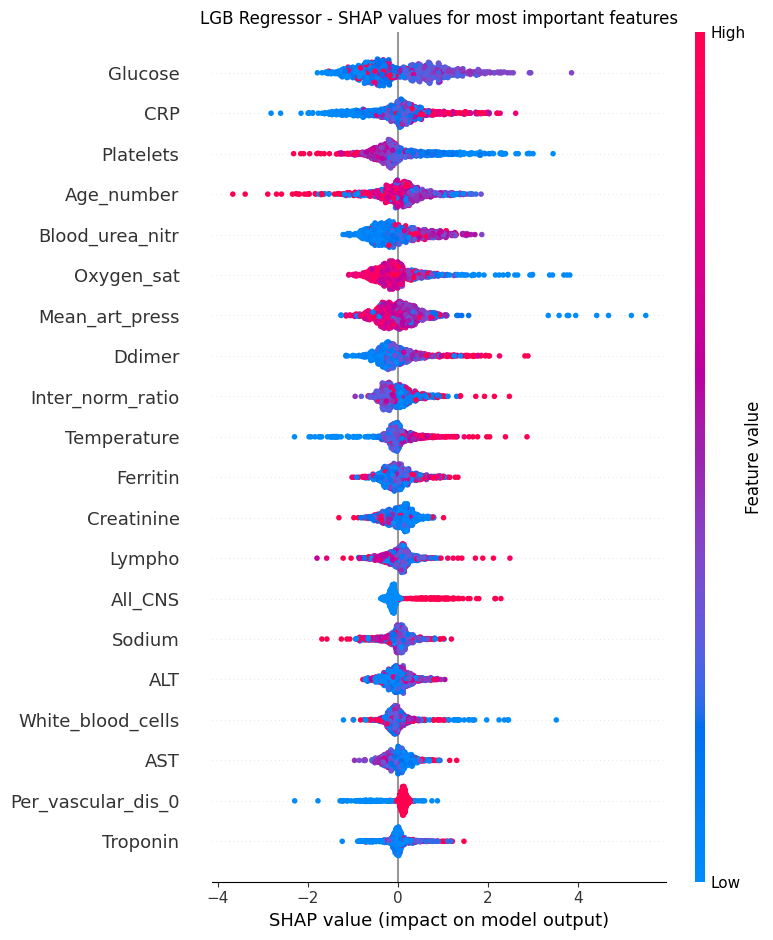

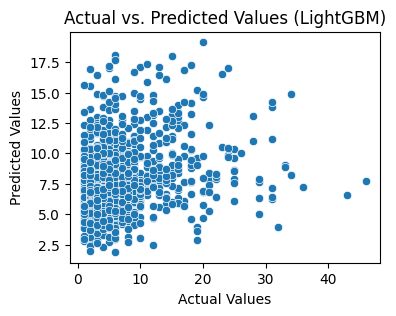

In [116]:
import lightgbm as lgb
import shap

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Create an LightGBM regression model
lgb_regressor = lgb.LGBMRegressor(random_state=42)
lgb_regressor.fit(train_x, train_y)

# Make predictions on the test set
pred_y = lgb_regressor.predict(test_x)

# Evaluate the LightGBM model
mse = mean_squared_error(test_y, pred_y)
mae = mean_absolute_error(test_y, pred_y)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

# Create object that can calculate SHAP values
explainer = shap.TreeExplainer(lgb_regressor)

# Calculate SHAP values for all of test_X
shap_values = explainer.shap_values(test_x)

# Make a summary plot of SHAP values
plt.figure(figsize=(3, 7))
plt.title("LGB Regressor - SHAP values for most important features")
shap.summary_plot(shap_values, test_x, feature_names=X.columns, show=False)
plt.show()

# Scatter plot of actual vs. predicted values
plt.figure(figsize=(4, 3))
sns.scatterplot(x=test_y, y=pred_y)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values (LightGBM)")
plt.show()


## CatBoost Regressor

Mean Absolute Error: 4.640297993169635
MSE: 41.475774784211914
RMSE: 6.4401688474924255


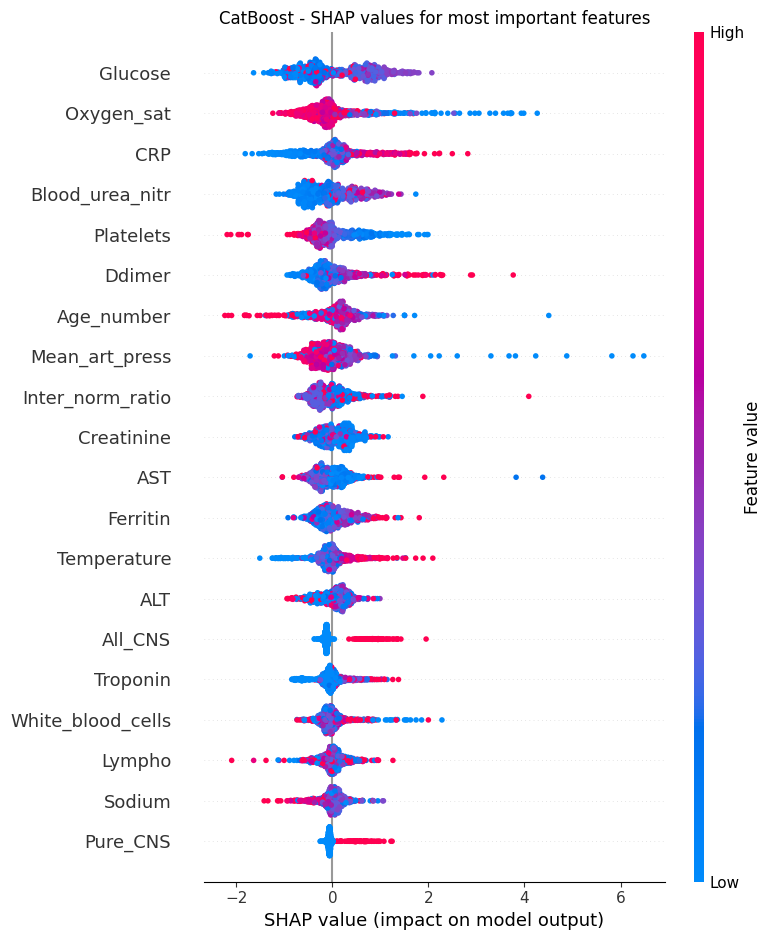

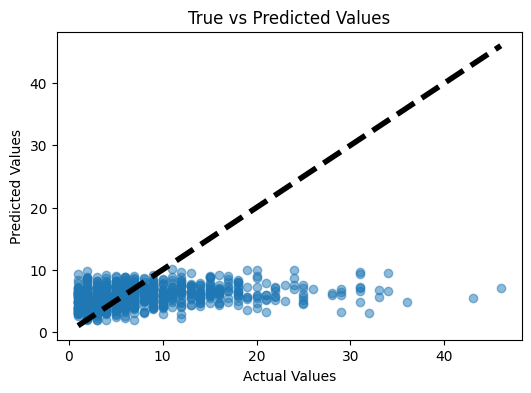

In [118]:
import shap

cat_regressor = cb.CatBoostRegressor(verbose=0)
cat_regressor.fit(train_x, train_y)

# Make predictions on the test set
pred_y = cat_regressor.predict(test_x)

# Evaluate the model
mse = mean_squared_error(test_y, pred_y)
mape = mean_absolute_percentage_error(test_y, pred_y)
rmse = np.sqrt(mse)
r2 = r2_score(test_y, pred_y)
mae = mean_absolute_error(test_y, pred_y)
print(f"Mean Absolute Error: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
#  SHAP values
explainer = shap.TreeExplainer(cat_regressor)
shap_values = explainer.shap_values(test_x)

# Make a summary plot of SHAP values
plt.figure(figsize=(3, 7))
plt.title("CatBoost - SHAP values for most important features")
shap.summary_plot(shap_values, test_x, feature_names=X.columns, show=False)
plt.show()

# Plotting true vs predicted values
plt.figure(figsize=(6, 4))
plt.scatter(test_y, y_pred, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values")
# Use min and max from both actual and predicted values for a more accurate line
plt.plot([min(test_y.min(), y_pred.min()), max(test_y.max(), y_pred.max())], [min(test_y.min(), y_pred.min()), max(test_y.max(), y_pred.max())], 'k--', lw=4)
plt.show()


## Random Forest Regressor - 3 min

Mean Absolute Error: 4.799964530892448
MSE: 42.40498723455378
RMSE: 6.511911181408556


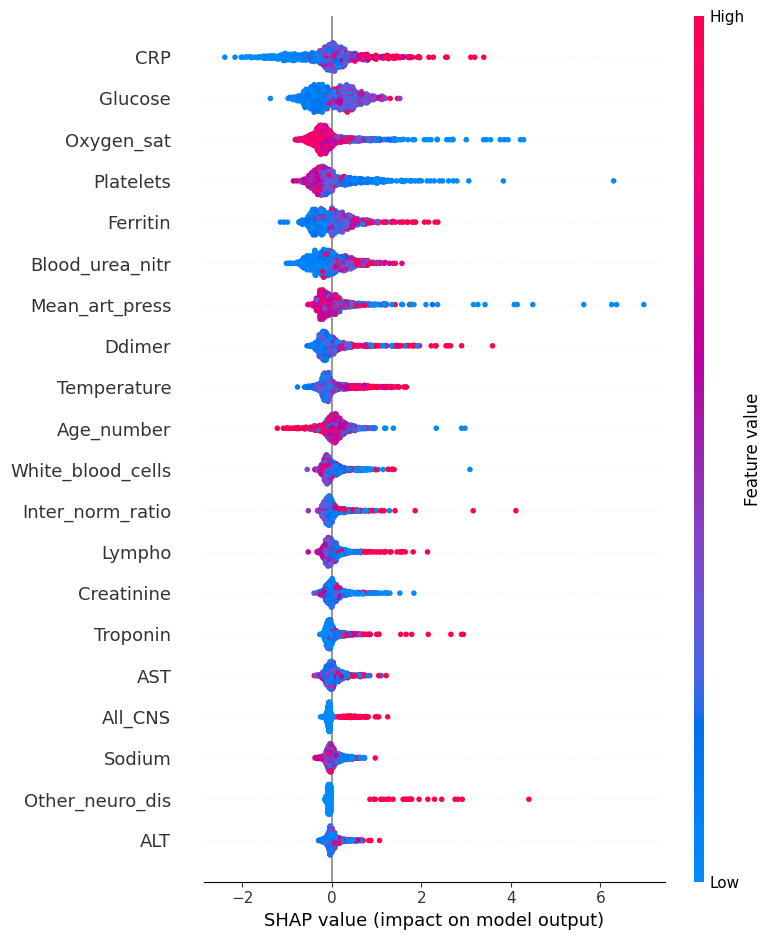

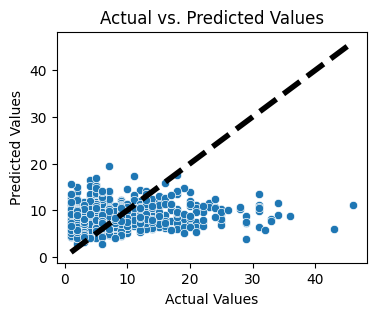

In [115]:
# Create a Random Forest Regressor
rf_regressor = RandomForestRegressor(random_state=42)
rf_regressor.fit(train_x, train_y)

# Make predictions on the test set
pred_y = rf_regressor.predict(test_x)

# Evaluate the model

mse = mean_squared_error(test_y, pred_y)
mape = mean_absolute_percentage_error(test_y, pred_y)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test_y, pred_y)

print(f"Mean Absolute Error: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

# Create object that can calculate SHAP values
explainer = shap.TreeExplainer(rf_regressor)

# Calculate SHAP values for all of test_X
shap_values = explainer.shap_values(test_x)

# Make a summary plot of SHAP values
shap.summary_plot(shap_values, test_x, feature_names=X.columns, show=False)
plt.show()

# Scatter plot of actual vs. predicted values
plt.figure(figsize=(4,3))
sns.scatterplot(x=test_y, y=pred_y)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.plot([min(test_y.min(), pred_y.min()), max(test_y.max(), pred_y.max())], [min(test_y.min(), pred_y.min()), max(test_y.max(), pred_y.max())], 'k--', lw=4)
plt.show()


## CATBOOST

Mean Absolute Error: 4.640297993169635
MSE: 41.475774784211914
RMSE: 6.4401688474924255


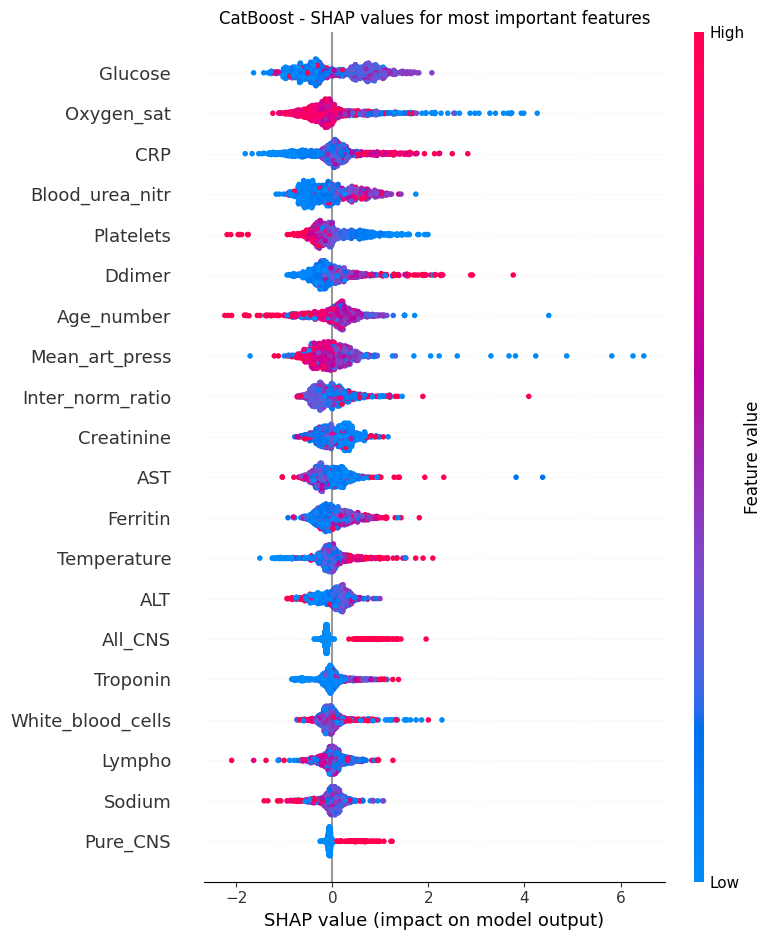

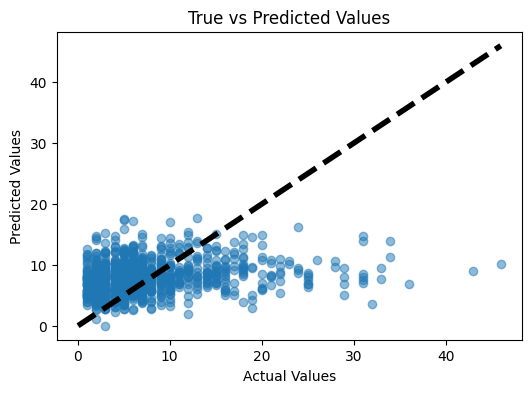

In [119]:
import shap

cat_regressor = cb.CatBoostRegressor(verbose=0)
cat_regressor.fit(train_x, train_y)

# Make predictions on the test set
pred_y = cat_regressor.predict(test_x)

# Evaluate the model
mse = mean_squared_error(test_y, pred_y)
mape = mean_absolute_percentage_error(test_y, pred_y)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test_y, pred_y)
print(f"Mean Absolute Error: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

# Create object that can calculate SHAP values
explainer = shap.TreeExplainer(cat_regressor)

# Calculate SHAP values for all of test_X
shap_values = explainer.shap_values(test_x)

# Make a summary plot of SHAP values
plt.figure(figsize=(3, 7))
plt.title("CatBoost - SHAP values for most important features")
shap.summary_plot(shap_values, test_x, feature_names=X.columns, show=False)
plt.show()

# Plotting true vs predicted values
plt.figure(figsize=(6, 4))
plt.scatter(test_y, pred_y, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values")
plt.plot([min(test_y.min(), pred_y.min()), max(test_y.max(), pred_y.max())], [min(test_y.min(), pred_y.min()), max(test_y.max(), pred_y.max())], 'k--', lw=4)
plt.show()


## KNN Regressor

KNN MSE: 49.18118993135012
KNN MAPE: 1.1514480585532676
KNN RMSE: 7.01293019581331
KNN R²: -0.15421823110485078


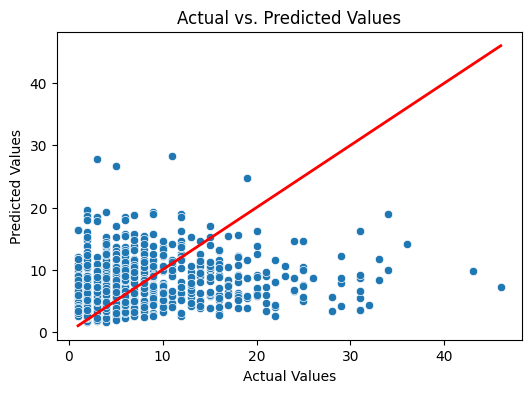

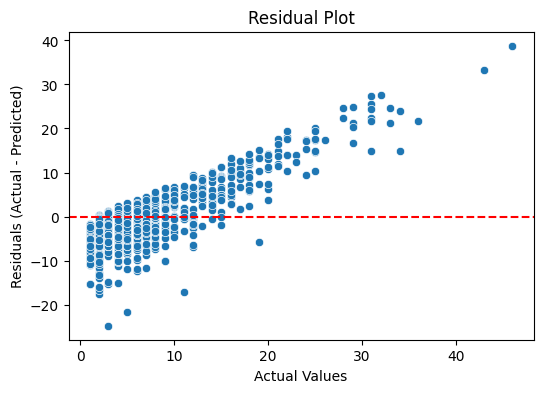

In [108]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# KNN Model for Regression
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

# Predictions for KNN model
knn_predictions = knn.predict(X_test)

# Evaluate the KNN model using MSE and MAPE
knn_mse = mean_squared_error(y_test, knn_predictions)
knn_mape = mean_absolute_percentage_error(y_test, knn_predictions)
knn_rmse = np.sqrt(knn_mse)
print(f'KNN MSE: {knn_mse}')
print(f'KNN MAPE: {knn_mape}')
print(f'KNN RMSE: {knn_rmse}')

# Scatter plot of actual vs. predicted values
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_test, y=knn_predictions)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r', lw=2)  # Ideal line for perfect predictions
plt.show()

# Residual plot
residuals = y_test - knn_predictions
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_test, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()


## KNN regressor - ladenie hyperparametrov

In [109]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Since this is regression, using KNeighborsRegressor
knn = KNeighborsRegressor()

# Define the grid of hyperparameters to search
param_grid = {
    'n_neighbors': [3, 5, 7, 10, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, scoring='neg_mean_absolute_percentage_error', verbose=1)

# Perform the grid search on the scaled data
grid_search.fit(X_train, y_train)

# Find the best hyperparameters
best_params = grid_search.best_params_
best_score = -grid_search.best_score_  # negated because scoring='neg_mean_absolute_percentage_error'

print('Best hyperparameters found:\n', best_params)
print(f'Best MAPE score from grid search: {best_score}')

# Evaluate the best model found by the grid search on the test data
best_knn = grid_search.best_estimator_
predictions = best_knn.predict(X_test)

# Calculate the MAPE for the test set
test_mape = mean_absolute_percentage_error(y_test, predictions)
print(f'Test MAPE of the best KNN model: {test_mape}')


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best hyperparameters found:
 {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}
Best MAPE score from grid search: 1.1436214992638447
Test MAPE of the best KNN model: 1.0596460882138494


## Linear Regression

Mean Absolute Error: 4.655008067255435
MSE: 41.337058357843276
RMSE: 6.429390201087758


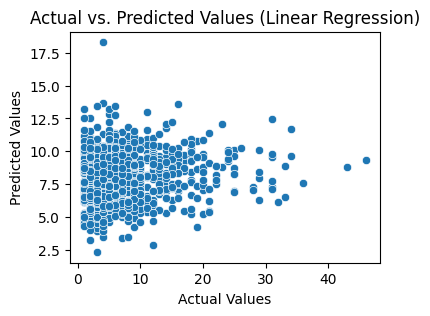

In [114]:
linear_regressor = LinearRegression()
linear_regressor.fit(train_x, train_y)

# Make predictions on the test set
pred_y = linear_regressor.predict(test_x)

# Evaluate the model
mse = mean_squared_error(test_y, pred_y)
mape = mean_absolute_percentage_error(test_y, pred_y)
rmse = np.sqrt(mse)
r2 = r2_score(test_y, pred_y)
mae = mean_absolute_error(test_y, pred_y)

print(f"Mean Absolute Error: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")


plt.figure(figsize=(4,3))
sns.scatterplot(x=test_y, y=pred_y)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values (Linear Regression)")
plt.show()



## XGB Regressor

Mean Absolute Error: 4.98284468342906
MSE: 46.11858970625907
RMSE: 6.791066904858107
R²: -0.08234300768467473


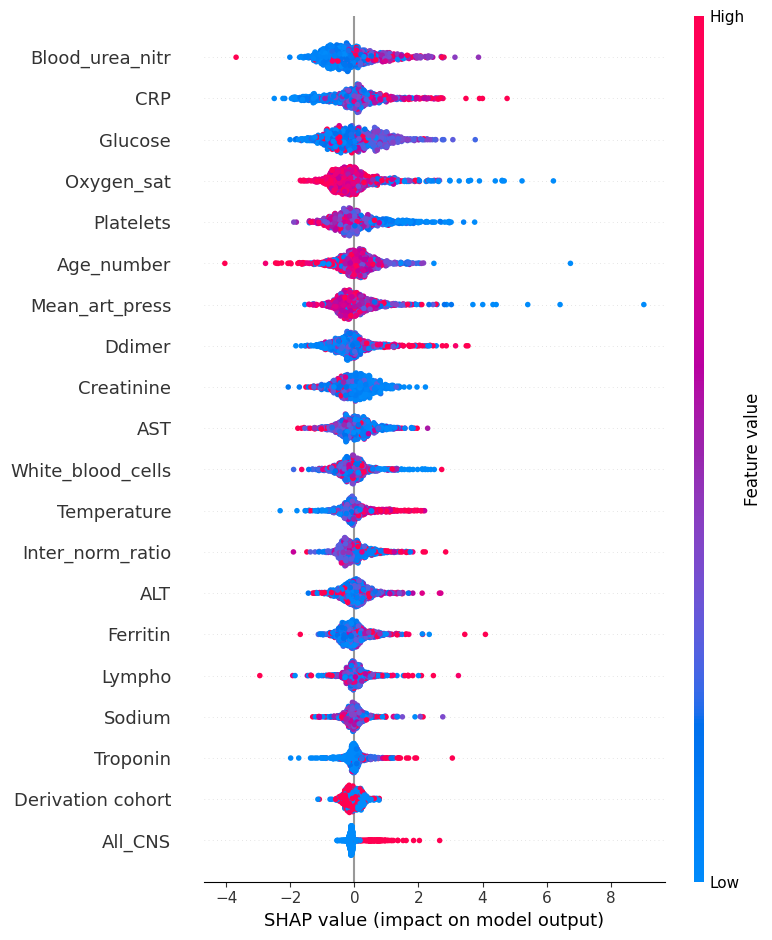

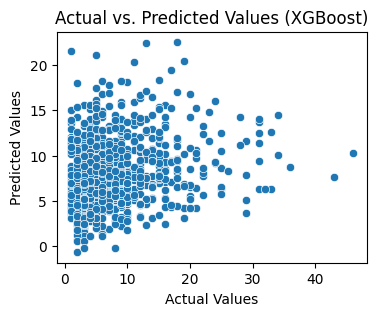

In [120]:
import xgboost as xgb

# Create an XGBoost regression model
xgb_regressor = xgb.XGBRegressor(objective ='reg:squarederror', random_state=42)
xgb_regressor.fit(train_x, train_y)

# Make predictions on the test set
pred_y = xgb_regressor.predict(test_x)

# Evaluate the model
mse = mean_squared_error(test_y, pred_y)
mape = mean_absolute_percentage_error(test_y, pred_y)
rmse = np.sqrt(mse)
r2 = r2_score(test_y, pred_y)
mae = mean_absolute_error(test_y, pred_y)
print(f"Mean Absolute Error: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")

# Create object that can calculate SHAP values
explainer = shap.TreeExplainer(xgb_regressor)

# Calculate SHAP values for all of test_X
shap_values = explainer.shap_values(test_x)

# Make a summary plot of SHAP values
plt.figure(figsize=(3, 7))
shap.summary_plot(shap_values, test_x, feature_names=X.columns, show=False)
plt.show()

# Scatter plot of actual vs. predicted values
plt.figure(figsize=(4, 3))
sns.scatterplot(x=test_y, y=pred_y)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values (XGBoost)")
plt.show()


# LOS - category

## Atribút LOS_class

In [121]:
data["Length_of_stay"].unique() # 12 different values

array([ 1.,  2., 15.,  9., 14.,  4.,  3.,  6.,  7., 11., 10.,  5., 25.,
       13., 17., 26.,  8., 12., 29., 16., 20., 34., 28., 22., 18., 31.,
       32., 49., 23., 36., 21., 27., 30., 33., 19., 56., 24., 39., 43.,
       35., 42., 45., 37., 38., 41., 40., 46., 50., 44., 52.])

In [127]:
# Define bin edges
bins = [0,10, 57]
# Define labels for each bin
labels = [0,1]

# Create a new column with bins
data['LOS_class'] = pd.cut(data['Length_of_stay'], bins=bins, labels=labels, right=False)

Vytvorenie stĺpca LOS_class

In [128]:
data['LOS_class'] =pd.to_numeric(data['LOS_class'])

<Axes: xlabel='Length_of_stay', ylabel='count'>

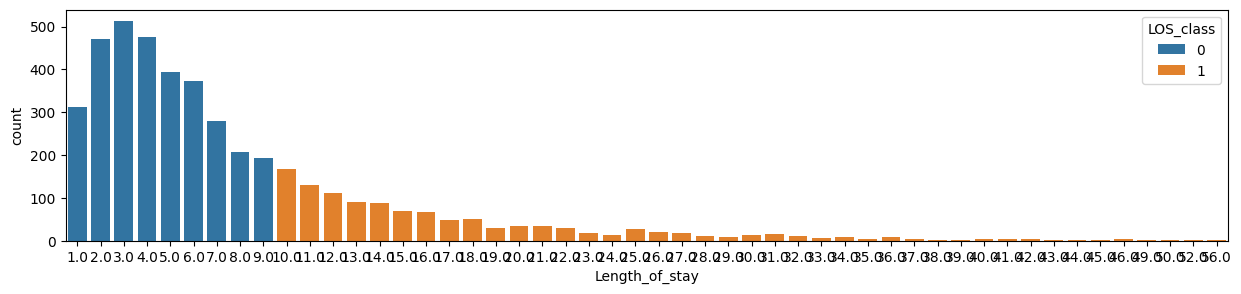

In [129]:
plt.figure(figsize=(15,3))
sns.countplot(x="Length_of_stay", hue="LOS_class",data=data)

<Axes: xlabel='LOS_class', ylabel='count'>

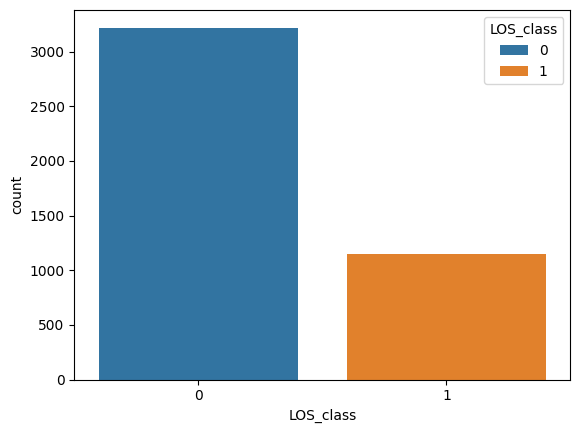

In [130]:
sns.countplot(x= "LOS_class", data=data, hue="LOS_class")

In [132]:
X = data.drop(columns=["Death","Severity","Length_of_stay", "LOS_class"])

y = data["LOS_class"]

In [133]:
from sklearn.model_selection import train_test_split
train_x, test_x, train_y, test_y = train_test_split(X,y, test_size=0.2, random_state=42)
print("Train_x :",train_x.shape)
print("Test_x :",test_x.shape)
print("Train_y :",train_y.shape)
print("Test_y :",test_y.shape)

Train_x : (3496, 50)
Test_x : (874, 50)
Train_y : (3496,)
Test_y : (874,)


## Základné modely pre binárnu klasifikáciu, či bude pacient dlhšie ako 7 dní

In [134]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


models = [
    ('RandomForest', RandomForestClassifier(n_estimators=100)),
    ('LGBM', LGBMClassifier()),
    ('XGB', XGBClassifier(use_label_encoder=False, eval_metric='logloss')),
    ('KNN', KNeighborsClassifier()),
    ('NaiveBayes', GaussianNB()),
    ('SVC', SVC(probability=True)),
    ('LogisticRegression', LogisticRegression(max_iter=1000)),
]

accuracy_scores = []
for name, model in models:
    cv_accuracy = np.mean(cross_val_score(model, X, y, cv=5, scoring='accuracy'))
    accuracy_scores.append((name, cv_accuracy))
    print(f"{name}: Mean cross-validation accuracy = {cv_accuracy:.4f}")

# Identify the model with the best accuracy score
best_model_accuracy = max(accuracy_scores, key=lambda x: x[1])
print(f"\nBest model based on accuracy is {best_model_accuracy[0]} with a score of {best_model_accuracy[1]:.4f}")


RandomForest: Mean cross-validation accuracy = 0.7394
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 921, number of negative: 2575
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001661 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3986
[LightGBM] [Info] Number of data points in the train set: 3496, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.263444 -> initscore=-1.028145
[LightGBM] [Info] Start training from score -1.028145
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 921, number of negative: 2575
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001646 seconds.
You can set `force_row_wise=true` to remove the overhead.
An

# Random Forest classifier

              precision    recall  f1-score   support

           0       0.98      0.74      0.85       850
           1       0.05      0.46      0.09        24

    accuracy                           0.74       874
   macro avg       0.51      0.60      0.47       874
weighted avg       0.95      0.74      0.83       874

Random Forest Accuracy on Train set : 0.9997139588100686
Random Forest Accuracy on Test set : 0.7368421052631579


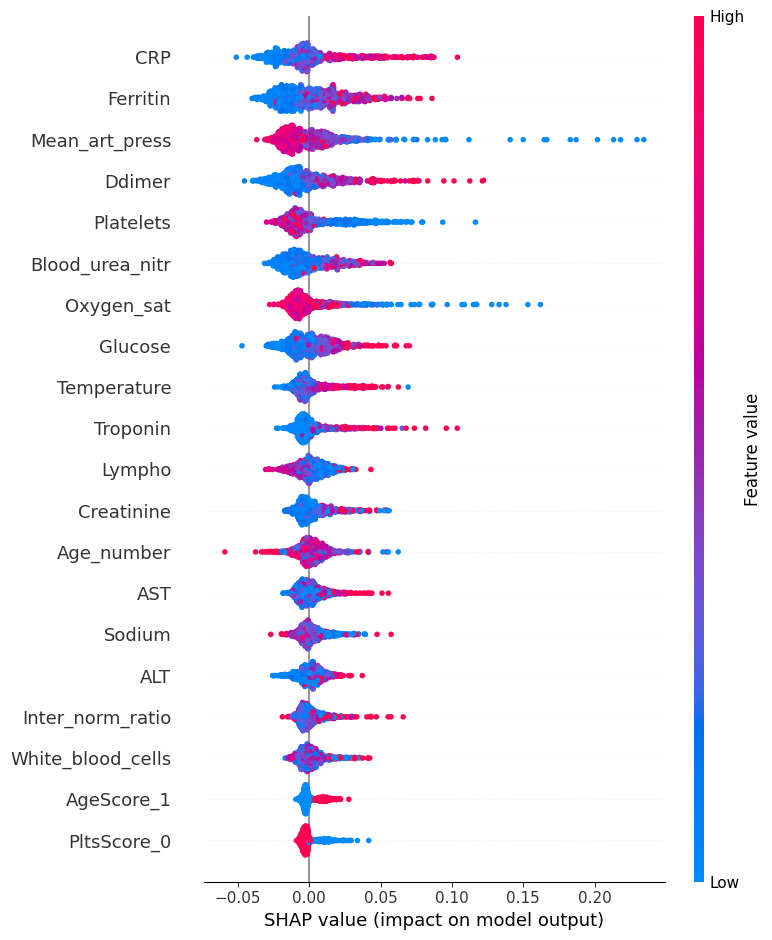

In [137]:
from sklearn.metrics import classification_report
rf = RandomForestClassifier()
rf.fit(train_x,train_y)

pred = rf.predict(test_x)
print(classification_report(pred, test_y))

print("Random Forest Accuracy on Train set :",rf.score(train_x, train_y))
print("Random Forest Accuracy on Test set :",rf.score(test_x, test_y))

# Create object that can calculate shap values
explainer = shap.TreeExplainer(rf)

# Calculate shap_values for
shap_values = explainer.shap_values(test_x)

# Make plot. Index of [1] is explained in text below.
shap.summary_plot(shap_values[1], test_x)

# KNN

In [138]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(train_x, train_y)

# Predict on the test set
pred = knn.predict(test_x)
print("Classification Report:\n", classification_report(test_y, pred))
# Print accuracy
print("KNN Accuracy on Test set:", knn.score(test_x, test_y))

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.83      0.79       646
           1       0.34      0.25      0.29       228

    accuracy                           0.68       874
   macro avg       0.55      0.54      0.54       874
weighted avg       0.65      0.68      0.66       874

KNN Accuracy on Test set: 0.6784897025171625


# XGB

              precision    recall  f1-score   support

           0       0.90      0.76      0.82       770
           1       0.18      0.40      0.25       104

    accuracy                           0.72       874
   macro avg       0.54      0.58      0.54       874
weighted avg       0.82      0.72      0.76       874

XGBoost Accuracy: 0.7162471395881007


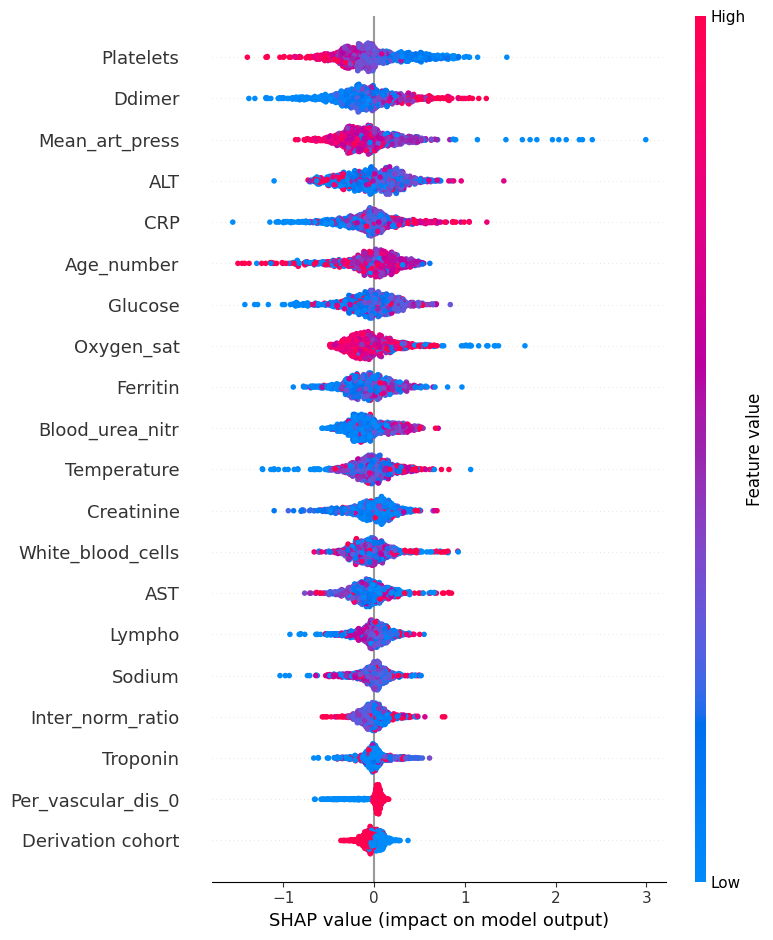

In [141]:
import xgboost as xgb

# Create an XGBoost model
xgb_model = xgb.XGBClassifier()

# Train the XGBoost model
xgb_model.fit(train_x, train_y)

# Make predictions on the test set
predictions = xgb_model.predict(test_x)

print(classification_report(predictions, test_y))
# Calculate accuracy
accuracy = accuracy_score(test_y, predictions)
print("XGBoost Accuracy:", accuracy)

# Create object that can calculate shap values
explainer = shap.TreeExplainer(xgb_model)

# calculate shap values. This is what we will plot.
# Calculate shap_values for all of val_X rather than a single row, to have more data for plot.
shap_values = explainer.shap_values(test_x)

# Make plot. Index of [1] is explained in text below.
shap.summary_plot(shap_values, test_x)

# MLP

In [142]:
from sklearn.neural_network import MLPClassifier

# Create a neural network model
nn_model = MLPClassifier()

# Train the neural network model
nn_model.fit(train_x, train_y)

# Make predictions on the test set
predictions = nn_model.predict(test_x)

print(classification_report(predictions, test_y))

# Calculate accuracy
accuracy = accuracy_score(test_y, predictions)
print("multilayer perceptron Neural Network Accuracy:", accuracy)


              precision    recall  f1-score   support

           0       0.84      0.76      0.80       709
           1       0.26      0.36      0.30       165

    accuracy                           0.69       874
   macro avg       0.55      0.56      0.55       874
weighted avg       0.73      0.69      0.70       874

multilayer perceptron Neural Network Accuracy: 0.6853546910755148


Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.


# LGBMClassifier

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 923, number of negative: 2573
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001627 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3965
[LightGBM] [Info] Number of data points in the train set: 3496, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.264016 -> initscore=-1.025199
[LightGBM] [Info] Start training from score -1.025199
              precision    recall  f1-score   support

           0       0.95      0.75      0.84       815
           1       0.12      0.47      0.20        59

    accuracy                           0.74       874
   macro avg       0.54      0.61      0.52       874
weighted avg       0.90      0.74      0.80       874

Accuracy on Train set : 0.8930205949656

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


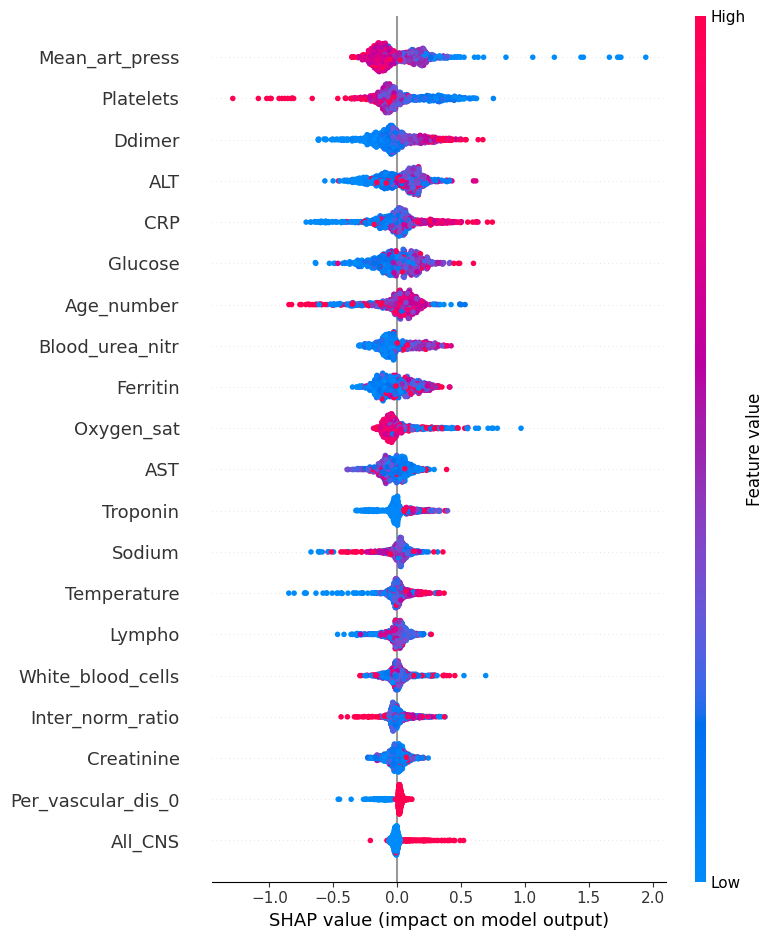

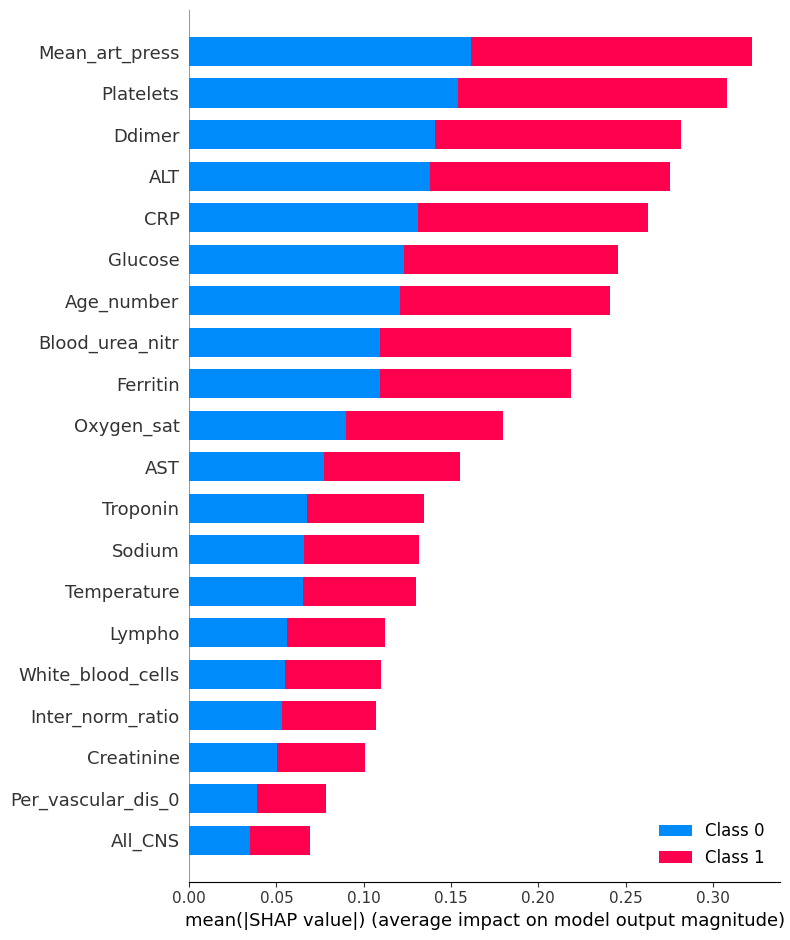

In [140]:
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score


lgb = LGBMClassifier(num_leaves = 20)

lgb.fit(train_x, train_y)

pred = lgb.predict(test_x)

y_prob = lgb.predict_proba(test_x)

print(classification_report(pred, test_y))
print("Accuracy on Train set :",lgb.score(train_x, train_y))
accuracy = accuracy_score(test_y, pred)
print(f"Accuracy on Test set: {accuracy}")

explainer = shap.TreeExplainer(lgb)

# calculate shap values. This is what we will plot.
shap_values = explainer.shap_values(test_x)

# Make plot
shap.summary_plot(shap_values[1], test_x)

shap.summary_plot(shap_values, test_x)